### Notebook organizing key questions, analyses and figures: 

1.⁠ ⁠how are glaciers evolving from 2000-2019 (MB timeseries for all glaciers, report changes by region.) 
2. using the MB timeseries and historic streamflow data, how much are glaciers contributing to streamflow (over full timeseries, in peak ablation, and pre vs post 2010 to look at megadrought impact). 
3. how is the relative importance of glaciers changing through time and with drought?

In [ ]:
# Cell 0: Setup, paths, BASIN_SET toggle, data loading
import os, pickle, calendar, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import to_hex
from scipy import stats
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
warnings.filterwarnings('ignore')

# ── BASIN SET TOGGLE ────────────────────────────────────────────────────────
# 'subbasin' = full 137 CAMELS sub-basin set (default, primary analysis)
# 'grouped'  = jerarquia=0 grouped main-basin set (Alexis's hierarchical
#              grouping request) — flip this ONE variable to rerun every
#              downstream cell on the grouped basin set instead.
BASIN_SET = 'subbasin'   # <-- change to 'grouped' to rerun on grouped basins

# ── Paths ─────────────────────────────────────────────────────────────────
BASE_PATH    = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT  = f'{BASE_PATH}/Output'
CAMELS_FULL  = f'{BASE_PATH}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
RGI_PATH     = f'{BASE_PATH}/files_chile_OGGM_climate_comparison/RGI_BNA_Clusters.csv'
BOUNDS_PATH  = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'

OUT_DIR_SUB  = f'{OUTPUT_ROOT}/all_chile_results_v2'
OUT_DIR_GRP  = f'{OUTPUT_ROOT}/grouped_basin_results'
OUT_DIR      = OUT_DIR_SUB if BASIN_SET == 'subbasin' else OUT_DIR_GRP

LAG_DIR      = f'{OUT_DIR_SUB}/lag_analysis'      # lag analysis always vs subbasin
DROUGHT_DIR  = f'{OUT_DIR}/megadrought_analysis'
os.makedirs(DROUGHT_DIR, exist_ok=True)
os.makedirs(LAG_DIR, exist_ok=True)

# ── Constants ────────────────────────────────────────────────────────────
YEARS         = list(range(2000, 2020))
MONTHS        = list(range(1, 13))
WATER_DENSITY = 1000
CLUSTERS      = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
DATASETS      = {'CR2MET': 'TC', 'ERA5': 'ERA5', 'CRU': 'CRU'}
DS_COLORS     = {'CR2MET': '#1f77b4', 'ERA5': '#ff7f0e', 'CRU': '#2ca02c'}
REGION_LABELS = {
    'OT3': 'Altiplano',     'DA1': 'Dry Andes N',
    'DA2': 'Dry Andes C',   'DA3': 'Dry Andes S',
    'WA1': 'Wet Andes N',   'WA2': 'Wet Andes C',
    'WA3': 'N Patagonia',   'WA4': 'S Patagonia',
    'WA5': 'Patagonia',     'WA6': 'Tierra del Fuego',
}
BASELINE     = list(range(2000, 2010))
DROUGHT_DEFS = {
    'Baseline (2000-2009)':  list(range(2000, 2010)),
    'Drought (2010-2019)':   list(range(2010, 2020)),
}
DROUGHT_COLORS = {
    'Baseline (2000-2009)':  '#2ecc71',
    'Drought (2010-2019)':   '#f39c12',
}
SUMMER, WINTER = [12, 1, 2], [6, 7, 8]
FMA_MONTHS = [2, 3, 4]
PCTILE_THRESHOLD = 20   # basin-relative hydrologic drought threshold

def nc_path(dataset_name, cluster):
    tag = DATASETS[dataset_name]
    return (f'{OUTPUT_ROOT}/{dataset_name}/{cluster}/'
            f'run_output_2000_2019_hydro_{tag}_{cluster}.nc')

def sig_stars(p):
    """Standard significance stars. Used in EVERY stats cell in this
    notebook per project convention: always report p-value + stars."""
    if pd.isna(p):
        return 'n/a'
    if p < 0.001:
        return '***'
    if p < 0.01:
        return '**'
    if p < 0.05:
        return '*'
    return 'ns'

def basins_in_cluster(cluster):
    """Works identically for BASIN_SET='subbasin' or 'grouped' — both
    store info['clusters'] as a list, so membership check is uniform.
    Use this everywhere instead of ad hoc info['clusters'][0] filtering
    (which silently mishandles any basin belonging to >1 cluster)."""
    return [gid for gid, info in GAUGE_INFO_FRAC.items()
            if cluster in info['clusters']]

# ── Load RESULTS (branches on BASIN_SET) ────────────────────────────────────
print(f'BASIN_SET = "{BASIN_SET}"  |  loading from {OUT_DIR}')

if BASIN_SET == 'subbasin':
    with open(f'{OUT_DIR}/RESULTS.pkl', 'rb') as f:
        RESULTS = pickle.load(f)
    print(f'  RESULTS loaded: {len(RESULTS["CR2MET"])} gauges (sub-basin)')

    nested_csv = pd.read_csv(f'{OUT_DIR}/spatial_join_nested.csv',
                             dtype={'gauge_id': str})
    comp_csv   = pd.read_csv(f'{OUT_DIR}/gauge_completeness_assessment.csv',
                             dtype={'gauge_id': str})

    GAUGE_INFO = {}
    for gauge_id, grp in nested_csv.groupby('gauge_id'):
        GAUGE_INFO[gauge_id] = {
            'gauge_name':       grp['gauge_name'].iloc[0],
            'rgi_ids':          grp['RGIId'].tolist(),
            'n_glaciers':       len(grp),
            'glacier_area_km2': grp['Area'].sum(),
            'basin_area_km2':   grp['area_km2'].iloc[0],
            'clusters':         sorted(grp['Cluster'].unique().tolist()),
            'cen_lat':          grp['CenLat'].mean(),
            'cen_lon':          grp['CenLon'].mean(),
        }

    gauges_in_results = set(RESULTS['CR2MET'].keys())
    GAUGE_INFO_FRAC = {}
    for _, row in comp_csv[comp_csv['passes'] == True].iterrows():
        gauge_id = str(row['gauge_id'])
        if gauge_id not in gauges_in_results or gauge_id not in GAUGE_INFO:
            continue
        info = dict(GAUGE_INFO[gauge_id])
        res = RESULTS['CR2MET'].get(gauge_id)
        info['complete_years'] = (res['complete_years']
                                  if res is not None and 'complete_years' in res
                                  else YEARS)
        GAUGE_INFO_FRAC[gauge_id] = info

    excluded = pd.read_csv(f'{OUT_DIR}/excluded_high_frac_gauges.csv',
                           dtype={'gauge_id': str})
    for gauge_id in excluded['gauge_id'].tolist():
        GAUGE_INFO_FRAC.pop(gauge_id, None)

else:  # BASIN_SET == 'grouped'
    with open(f'{OUT_DIR_GRP}/RESULTS_grouped.pkl', 'rb') as f:
        RESULTS = pickle.load(f)
    print(f'  RESULTS loaded: {len(RESULTS["CR2MET"])} gauges (grouped)')

    GAUGE_INFO_FRAC = {}
    for gid, res in RESULTS['CR2MET'].items():
        if res is None:
            continue
        GAUGE_INFO_FRAC[gid] = {
            'gauge_name':       res['gauge_name'],
            'clusters':         res['clusters'],
            'cen_lat':          res['cen_lat'],
            'glacier_area_km2': res['glacier_area_km2'],
            'basin_area_km2':   res['basin_area_km2'],
            'complete_years':   res['complete_years'],
            'rgi_ids':          [],
        }

print(f'  GAUGE_INFO_FRAC: {len(GAUGE_INFO_FRAC)} basins')
print('Cell 0 complete')

BASIN_SET = "subbasin"  |  loading from /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/all_chile_results_v2
  RESULTS loaded: 143 gauges (sub-basin)
  GAUGE_INFO_FRAC: 137 basins
Cell 0 complete


# Start with model validation and dataset comparison

In [40]:
# Load Hugonnet geodetic reference and per-cluster glacier lists

from oggm import utils
geodetic_ref = utils.get_geodetic_mb_dataframe()
geodetic_ref = geodetic_ref[geodetic_ref['period'] == '2000-01-01_2020-01-01']

base_path = f'{OUTPUT_ROOT}/'
datasets  = ['CR2MET', 'ERA5', 'CRU']
colors    = {'CR2MET': '#e74c3c', 'ERA5': '#3498db', 'CRU': '#2ecc71'}

# FIXED: glacier_lists is now built directly from RGI_BNA_Clusters.csv
# (the cluster's full glacier assignment), NOT from CAMELS gauge/basin
# rgi_ids. The old version routed through basins_in_cluster(), which
# only returns glaciers attached to a streamflow gauge -- WA5 has ~0
# CAMELS gauges, so it silently came back empty even though it has 711
# real, geodetically-matched glaciers sitting in RGI_BNA_Clusters.csv.
rgi_clusters_df = pd.read_csv(RGI_PATH)

glacier_lists = {}
for cl in CLUSTERS:
    cl_rgi_ids = set(rgi_clusters_df[rgi_clusters_df['Cluster'] == cl]['RGIId'])
    glacier_lists[cl] = {
        'with_gmb': [g for g in cl_rgi_ids if geodetic_ref is not None
                     and g in geodetic_ref.index]
    }
    print(f'{cl}: {len(glacier_lists[cl]["with_gmb"])} glaciers with GMB')

OT3: 34 glaciers with GMB
DA1: 422 glaciers with GMB
DA2: 200 glaciers with GMB
DA3: 410 glaciers with GMB
WA1: 678 glaciers with GMB
WA2: 2924 glaciers with GMB
WA3: 447 glaciers with GMB
WA4: 4749 glaciers with GMB
WA5: 711 glaciers with GMB
WA6: 2671 glaciers with GMB


In [41]:
# N glaciers and area matched per dataset per cluster (QA table)
print('N glaciers and total area (km²) per dataset per cluster:')
header = f'{"Cluster":<8}' + ''.join(f'{ds:>10}{"(km²)":>8}' for ds in datasets + ['GMB'])
print(header)
print('-' * (8 + 18 * (len(datasets) + 1)))

for cl in CLUSTERS:
    row = f'{cl:<8}'
    for dataset in datasets:
        mb_file = f'{base_path}{dataset}/{cl}/mb.csv'
        if os.path.exists(mb_file) and geodetic_ref is not None:
            mb_df     = pd.read_csv(mb_file).set_index('rgi_id')
            year_cols = mb_df.columns[:20]
            ran       = mb_df[year_cols].dropna(how='all').index.tolist()
            matched   = [g for g in ran if g in geodetic_ref.index]
            n, area   = len(matched), geodetic_ref.loc[matched, 'area'].sum() / 1e6
        else:
            n, area = 0, 0.0
        row += f'{n:>10}{area:>7.1f} '
    if geodetic_ref is not None:
        gmb_glaciers = glacier_lists[cl]['with_gmb']
        n_gmb    = len(gmb_glaciers)
        area_gmb = geodetic_ref.loc[gmb_glaciers, 'area'].sum() / 1e6
        row += f'{n_gmb:>10}{area_gmb:>7.1f} '
    print(row)

print('\nSection 0 complete — proceed to Section 1 (Q1: MB evolution)')

N glaciers and total area (km²) per dataset per cluster:
Cluster     CR2MET   (km²)      ERA5   (km²)       CRU   (km²)       GMB   (km²)
--------------------------------------------------------------------------------
OT3             34   13.2         34   13.2         34   13.2         34   13.2 
DA1            422  148.1        421  148.1        421  148.1        422  148.1 
DA2            200  253.9        200  253.9        200  253.9        200  253.9 
DA3            410  390.6        410  390.6        410  390.6        410  390.6 
WA1            670  304.5        670  304.5        671  307.8        678  307.9 
WA2           2915 1736.3       2914 1735.9       2912 1734.2       2924 1737.9 
WA3            44710946.5        44710946.5        44510946.4        44710946.5 
WA4           4714 6468.8       4724 6470.2       4701 6465.6       4749 6474.0 
WA5            707 2588.6        709 2588.7        704 2585.6        711 2588.7 
WA6           2604 4580.7       2631 4591.9       26

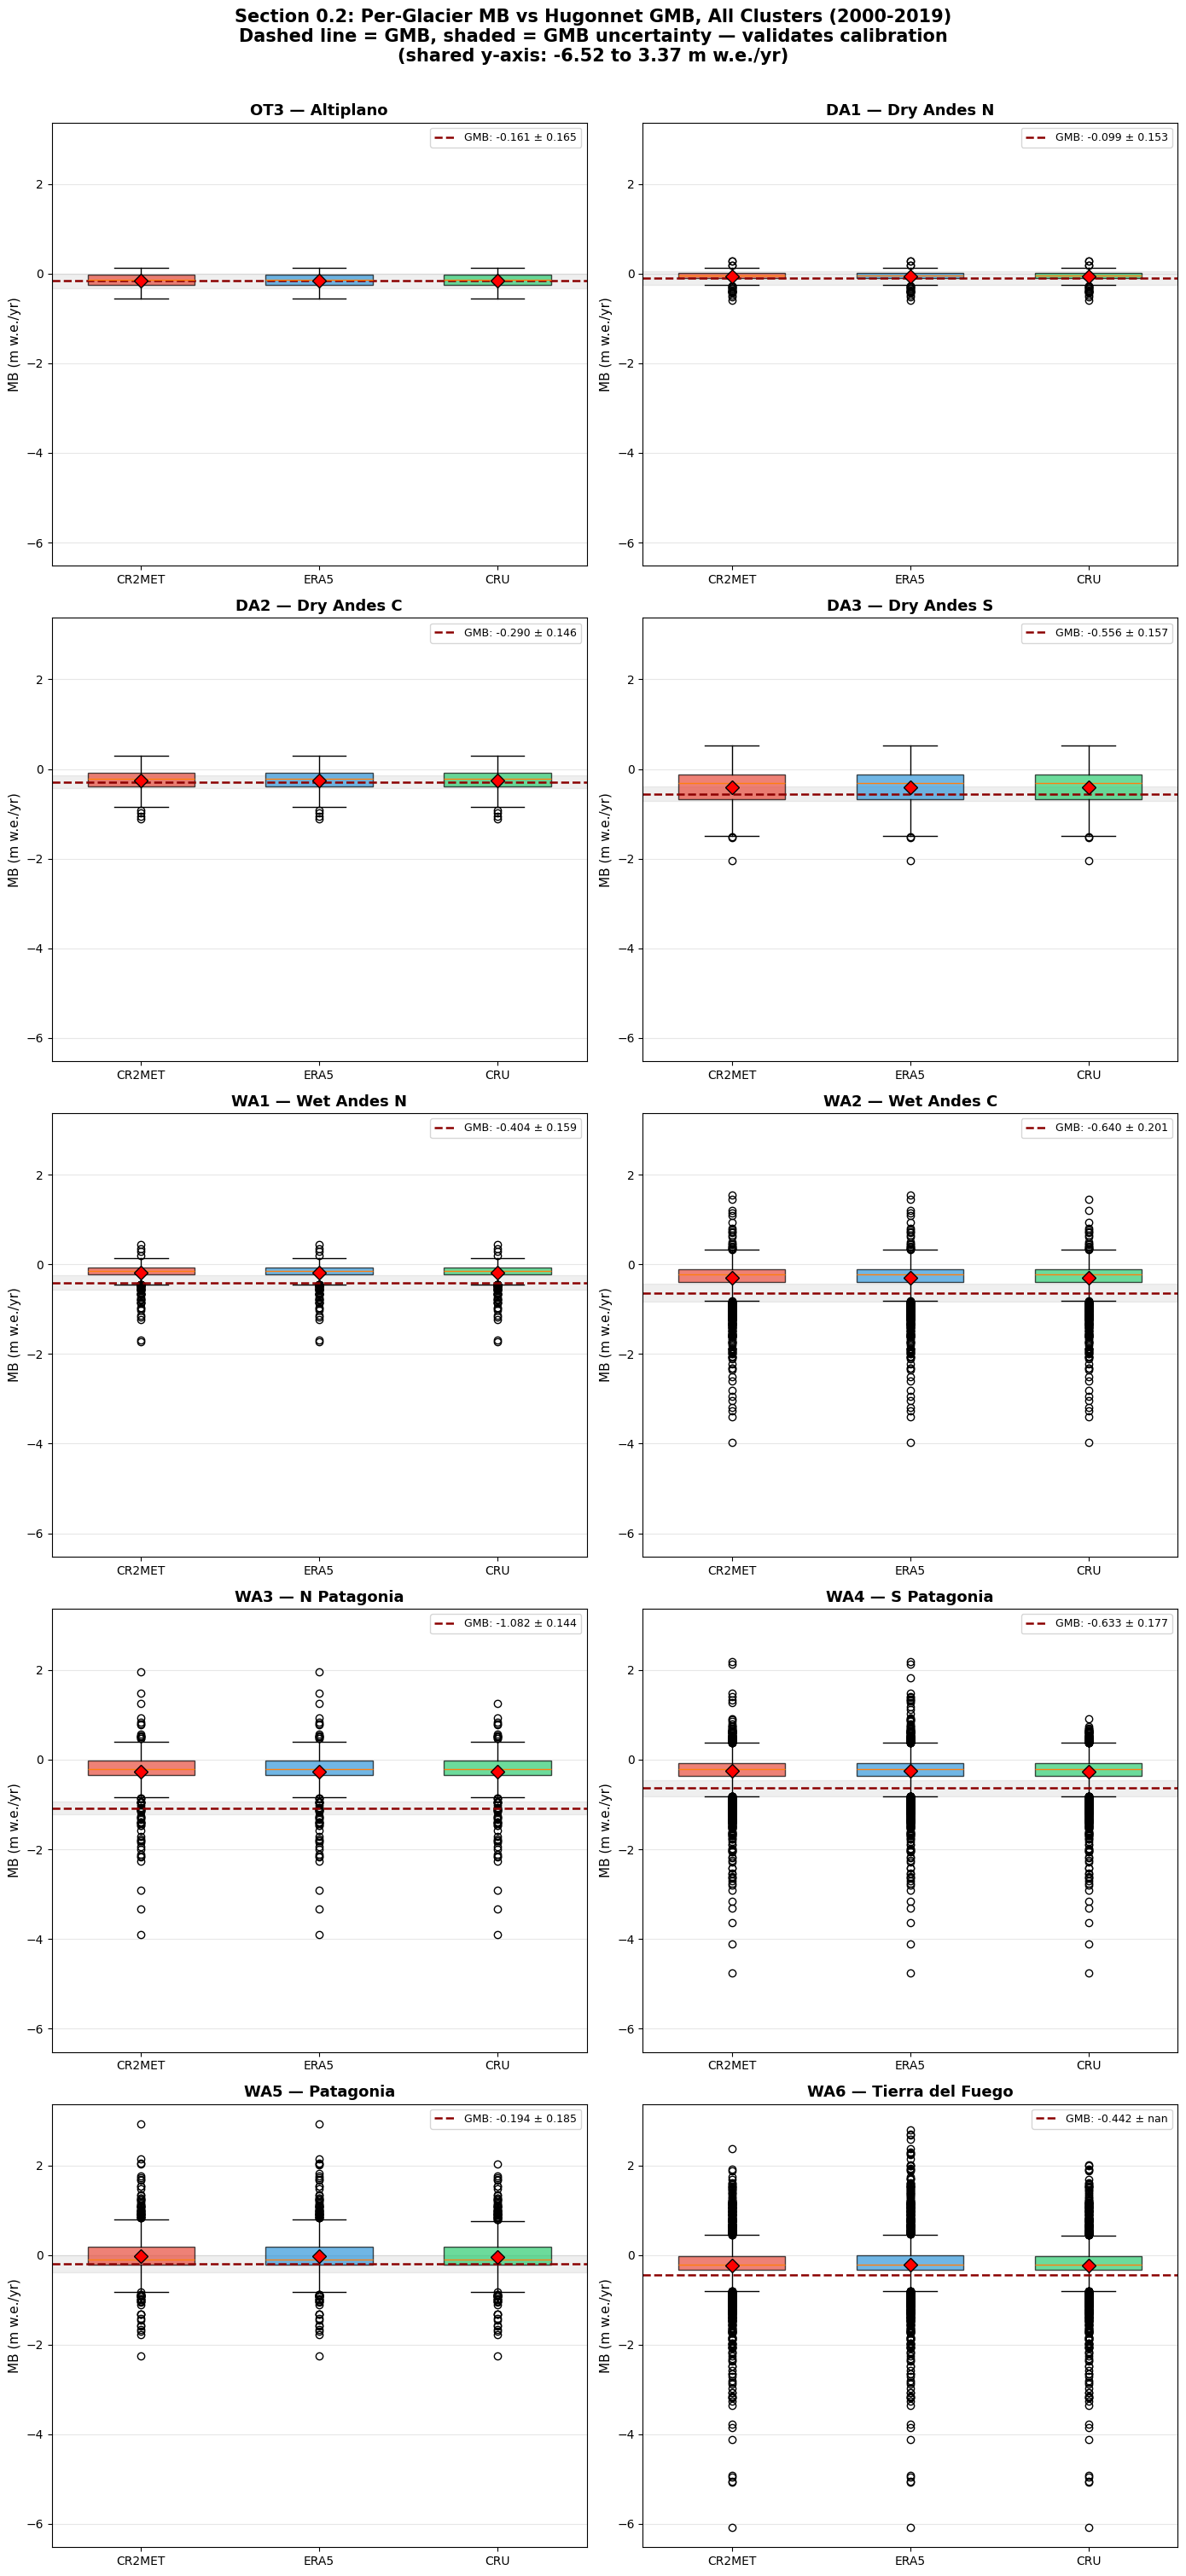

In [42]:
# SMB vs GMB validation, per-glacier boxplot, ALL clusters (shared y-axis, tall panels)

# ── First pass: collect all data + compute global y-limits ────────────────
CLUSTER_DATA = {}
global_min, global_max = np.inf, -np.inf

for cl in CLUSTERS:
    cl_glacier_data = {}
    for dataset in datasets:
        mb_file = f'{base_path}{dataset}/{cl}/mb.csv'
        if not os.path.exists(mb_file):
            continue
        mb_df = pd.read_csv(mb_file).set_index('rgi_id')
        year_cols = mb_df.columns[:20]
        cl_glacier_data[dataset] = (mb_df[year_cols].mean(axis=1) / 1000).dropna()

    cl_matched = glacier_lists[cl]['with_gmb']
    cl_gmb, cl_gmb_err = np.nan, np.nan
    if cl_matched and geodetic_ref is not None:
        cl_weights = geodetic_ref.loc[cl_matched, 'area']
        cl_gmb = np.average(geodetic_ref.loc[cl_matched, 'dmdtda'] * 1000,
                            weights=cl_weights) / 1000
        cl_gmb_err = np.average(geodetic_ref.loc[cl_matched, 'err_dmdtda'] * 1000,
                                weights=cl_weights) / 1000

    CLUSTER_DATA[cl] = {'glacier_data': cl_glacier_data,
                        'gmb': cl_gmb, 'gmb_err': cl_gmb_err}

    for vals in cl_glacier_data.values():
        if len(vals) > 0:
            global_min = min(global_min, vals.min())
            global_max = max(global_max, vals.max())
    if not np.isnan(cl_gmb):
        global_min = min(global_min, cl_gmb - cl_gmb_err)
        global_max = max(global_max, cl_gmb + cl_gmb_err)

y_range = global_max - global_min
YLIM = (global_min - 0.05*y_range, global_max + 0.05*y_range)

# ── Second pass: plot with shared y-axis, 5 rows x 2 cols, tall panels ────
fig, axes = plt.subplots(5, 2, figsize=(14, 30))
axes_flat = axes.flatten()

for ax, cl in zip(axes_flat, CLUSTERS):
    cl_glacier_data = CLUSTER_DATA[cl]['glacier_data']
    cl_gmb, cl_gmb_err = CLUSTER_DATA[cl]['gmb'], CLUSTER_DATA[cl]['gmb_err']

    box_data   = [cl_glacier_data[ds].values for ds in datasets if ds in cl_glacier_data]
    box_labels = [ds for ds in datasets if ds in cl_glacier_data]
    if not box_data:
        ax.set_visible(False)
        continue

    bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,
                    showmeans=True, widths=0.6,
                    meanprops=dict(marker='D', markerfacecolor='red',
                                   markersize=8, markeredgecolor='black'))
    for patch, ds in zip(bp['boxes'], box_labels):
        patch.set_facecolor(colors[ds])
        patch.set_alpha(0.7)

    if not np.isnan(cl_gmb):
        ax.axhline(cl_gmb, color='darkred', ls='--', lw=1.8,
                   label=f'GMB: {cl_gmb:.3f} ± {cl_gmb_err:.3f}')
        ax.axhspan(cl_gmb-cl_gmb_err, cl_gmb+cl_gmb_err, color='gray', alpha=0.12)
        ax.legend(fontsize=9, loc='best')

    ax.set_title(f'{cl} — {REGION_LABELS[cl]}', fontsize=13, fontweight='bold')
    ax.set_ylim(YLIM)
    ax.set_ylabel('MB (m w.e./yr)', fontsize=11)
    ax.tick_params(labelsize=10)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Section 0.2: Per-Glacier MB vs Hugonnet GMB, All Clusters (2000-2019)\n'
             'Dashed line = GMB, shaded = GMB uncertainty — validates calibration\n'
             f'(shared y-axis: {YLIM[0]:.2f} to {YLIM[1]:.2f} m w.e./yr)',
             fontsize=15, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section0_2_mb_validation_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

Section 0.3: National glacier water fluxes by dataset
UNITS: km³ of water-equivalent per year (averaged 2000-2019, n=19 yrs)
Dataset        Melt   Snowfall   Liq.prcp
---------------------------------------------------------------------------
CR2MET         74.1       50.3       50.9
ERA5          102.8       82.4       40.1
CRU            35.2       15.5       27.4


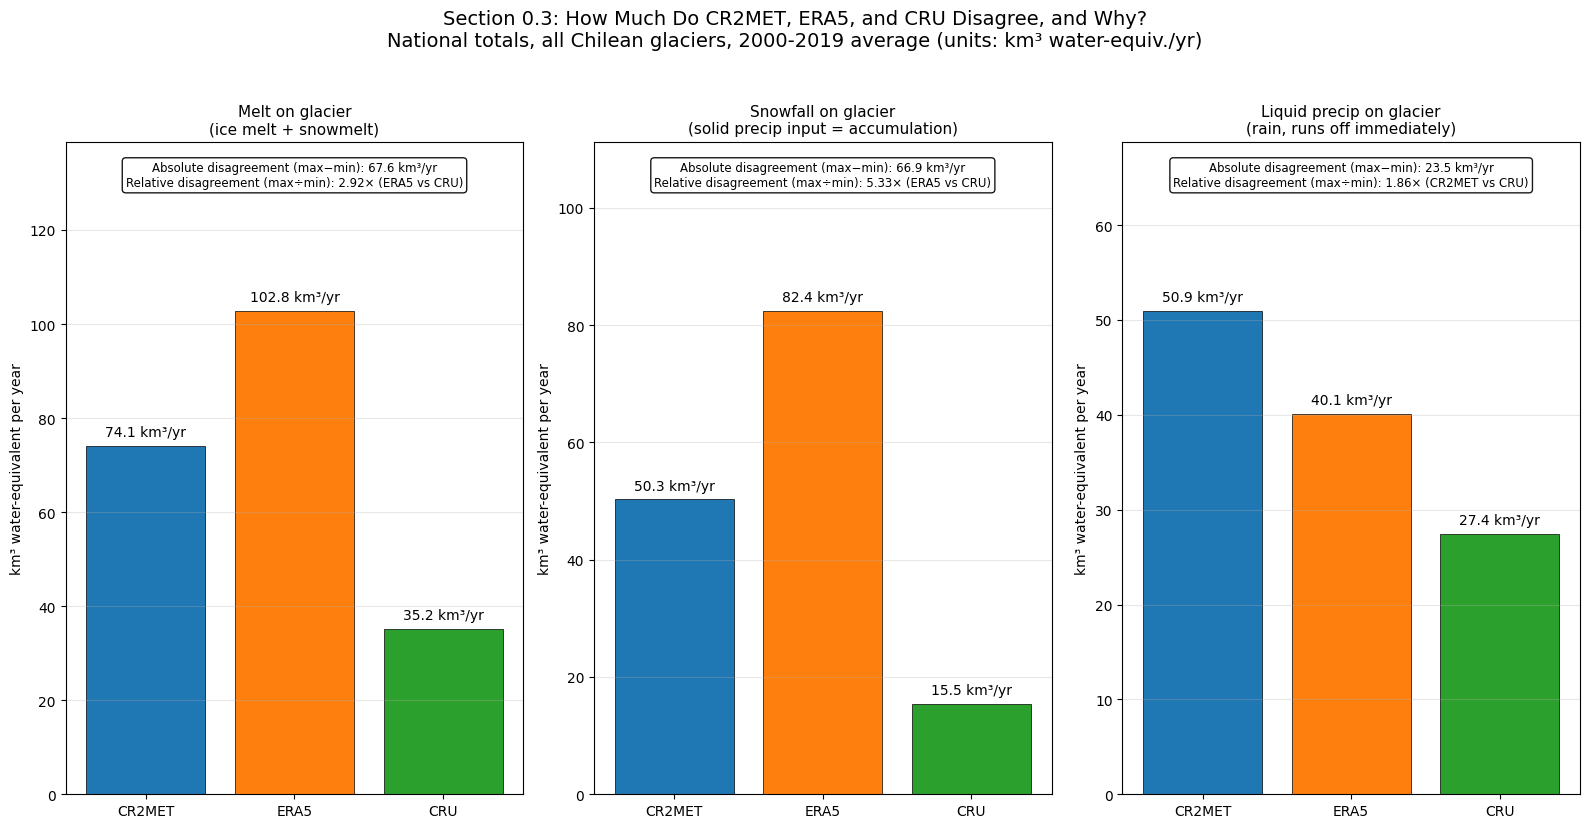


INTERPRETATION: Why do the three datasets disagree?
Melt disagreement (max−min across datasets):     67.6 km³/yr
Snowfall disagreement (max−min across datasets):  66.9 km³/yr
These two numbers differ by only 1.0%.

CONCLUSION: Melt disagreement ≈ Snowfall disagreement.
This means: the three datasets mainly disagree about HOW MUCH SNOW
FALLS on the glaciers (precipitation), not about how efficiently that
snow/ice melts (temperature). Because OGGM calibrates every dataset
to hit the SAME real-world mass-balance target (Hugonnet geodetic
data), a dataset that puts down more snow is forced to also produce
more melt, just to keep the glacier's overall mass balance correct.
So the melt differences you see between CR2MET/ERA5/CRU are mostly
a downstream CONSEQUENCE of their precipitation differences, driven
by the calibration constraint — not independent differences in how
each dataset represents temperature or melt physics.


In [43]:
# Dataset spread: national runoff decomposition (melt/snowfall/liq_prcp)
# Tests whether inter-dataset disagreement is PRECIPITATION-driven or
# TEMPERATURE-driven, exploiting OGGM's mu_star calibration constraint:
# every dataset's simulated MB is forced to match the same Hugonnet
# geodetic MB target. So if one dataset simulates more snowfall, melt
# MUST also be higher to still hit that same target MB — melt isn't
# free to vary independently of precipitation once calibrated.
#
# UNITS: raw OGGM variables are in kg (water-equivalent mass). Dividing
# by 1e12 converts kg -> km3 of water equivalent in one step
# (kg -> m3 via /1000 [water density], then m3 -> km3 via /1e9;
# 1000 x 1e9 = 1e12). Values below are km3 water-equiv per year,
# averaged over 2000-2019 (n=19 years; 1999 spinup year excluded).

results_spread = []
for ds_name, tag in DATASETS.items():
    total_melt = total_snowfall = total_liq_prcp = 0.0
    for cl in CLUSTERS:
        f = nc_path(ds_name, cl)
        if not os.path.exists(f):
            continue
        ds = xr.open_dataset(f)
        melt     = ds['melt_on_glacier_monthly'].values[1:, :, :]
        snowfall = ds['snowfall_on_glacier_monthly'].values[1:, :, :]
        liq_prcp = ds['liq_prcp_on_glacier_monthly'].values[1:, :, :]
        ds.close()
        total_melt     += np.nansum(melt)
        total_snowfall += np.nansum(snowfall)
        total_liq_prcp += np.nansum(liq_prcp)

    n = len(YEARS)
    results_spread.append({
        'dataset':        ds_name,
        'melt_km3yr':     total_melt     / 1e12 / n,
        'snowfall_km3yr': total_snowfall / 1e12 / n,
        'liq_prcp_km3yr': total_liq_prcp / 1e12 / n,
    })

df_spread = pd.DataFrame(results_spread).set_index('dataset')

print('Section 0.3: National glacier water fluxes by dataset')
print('UNITS: km³ of water-equivalent per year (averaged 2000-2019, n=19 yrs)')
print('='*75)
print(f'{"Dataset":8s} {"Melt":>10s} {"Snowfall":>10s} {"Liq.prcp":>10s}')
print('-'*75)
for ds_name, row in df_spread.iterrows():
    print(f'{ds_name:8s} {row["melt_km3yr"]:10.1f} {row["snowfall_km3yr"]:10.1f} '
          f'{row["liq_prcp_km3yr"]:10.1f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
spread_stats = {}
for ax, col, title in zip(axes,
    ['melt_km3yr', 'snowfall_km3yr', 'liq_prcp_km3yr'],
    ['Melt on glacier\n(ice melt + snowmelt)',
     'Snowfall on glacier\n(solid precip input = accumulation)',
     'Liquid precip on glacier\n(rain, runs off immediately)']):
    vals   = df_spread[col]
    spread = vals.max() - vals.min()
    ratio  = vals.max() / vals.min()
    spread_stats[col] = spread

    bars = ax.bar(vals.index, vals.values,
                  color=[DS_COLORS[d] for d in vals.index],
                  edgecolor='k', lw=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('km³ water-equivalent per year', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, vals.max() * 1.35)

    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + vals.max()*0.02,
                f'{val:.1f} km³/yr', ha='center', fontsize=10)

    ax.text(0.5, 0.97,
            f'Absolute disagreement (max−min): {spread:.1f} km³/yr\n'
            f'Relative disagreement (max÷min): {ratio:.2f}× '
            f'({vals.idxmax()} vs {vals.idxmin()})',
            transform=ax.transAxes, ha='center', va='top', fontsize=8.5,
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9))

fig.suptitle('Section 0.3: How Much Do CR2MET, ERA5, and CRU Disagree, and Why?\n'
             'National totals, all Chilean glaciers, 2000-2019 average '
             '(units: km³ water-equiv./yr)',
             fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section0_3_dataset_spread_decomposition.png',
            dpi=150, bbox_inches='tight')
plt.show()

# ── Plain-language interpretation ──────────────────────────────────────────
melt_spread = spread_stats['melt_km3yr']
snow_spread = spread_stats['snowfall_km3yr']
diff_pct = abs(melt_spread - snow_spread) / max(melt_spread, snow_spread) * 100

print(f'\n{"="*75}')
print('INTERPRETATION: Why do the three datasets disagree?')
print(f'{"="*75}')
print(f'Melt disagreement (max−min across datasets):     {melt_spread:.1f} km³/yr')
print(f'Snowfall disagreement (max−min across datasets):  {snow_spread:.1f} km³/yr')
print(f'These two numbers differ by only {diff_pct:.1f}%.\n')

if diff_pct < 20:
    print('CONCLUSION: Melt disagreement ≈ Snowfall disagreement.')
    print('This means: the three datasets mainly disagree about HOW MUCH SNOW')
    print('FALLS on the glaciers (precipitation), not about how efficiently that')
    print('snow/ice melts (temperature). Because OGGM calibrates every dataset')
    print('to hit the SAME real-world mass-balance target (Hugonnet geodetic')
    print('data), a dataset that puts down more snow is forced to also produce')
    print('more melt, just to keep the glacier\'s overall mass balance correct.')
    print('So the melt differences you see between CR2MET/ERA5/CRU are mostly')
    print('a downstream CONSEQUENCE of their precipitation differences, driven')
    print('by the calibration constraint — not independent differences in how')
    print('each dataset represents temperature or melt physics.')
else:
    print('CONCLUSION: Melt disagreement differs substantially from snowfall')
    print('disagreement. This likely means datasets disagree about melt for reasons')
    print('beyond just precipitation input — likely differences in simulated')
    print('temperature or melt efficiency independent of how much snow fell.')

## SECTION 1 — Q1: How are glaciers evolving from 2000-2019?

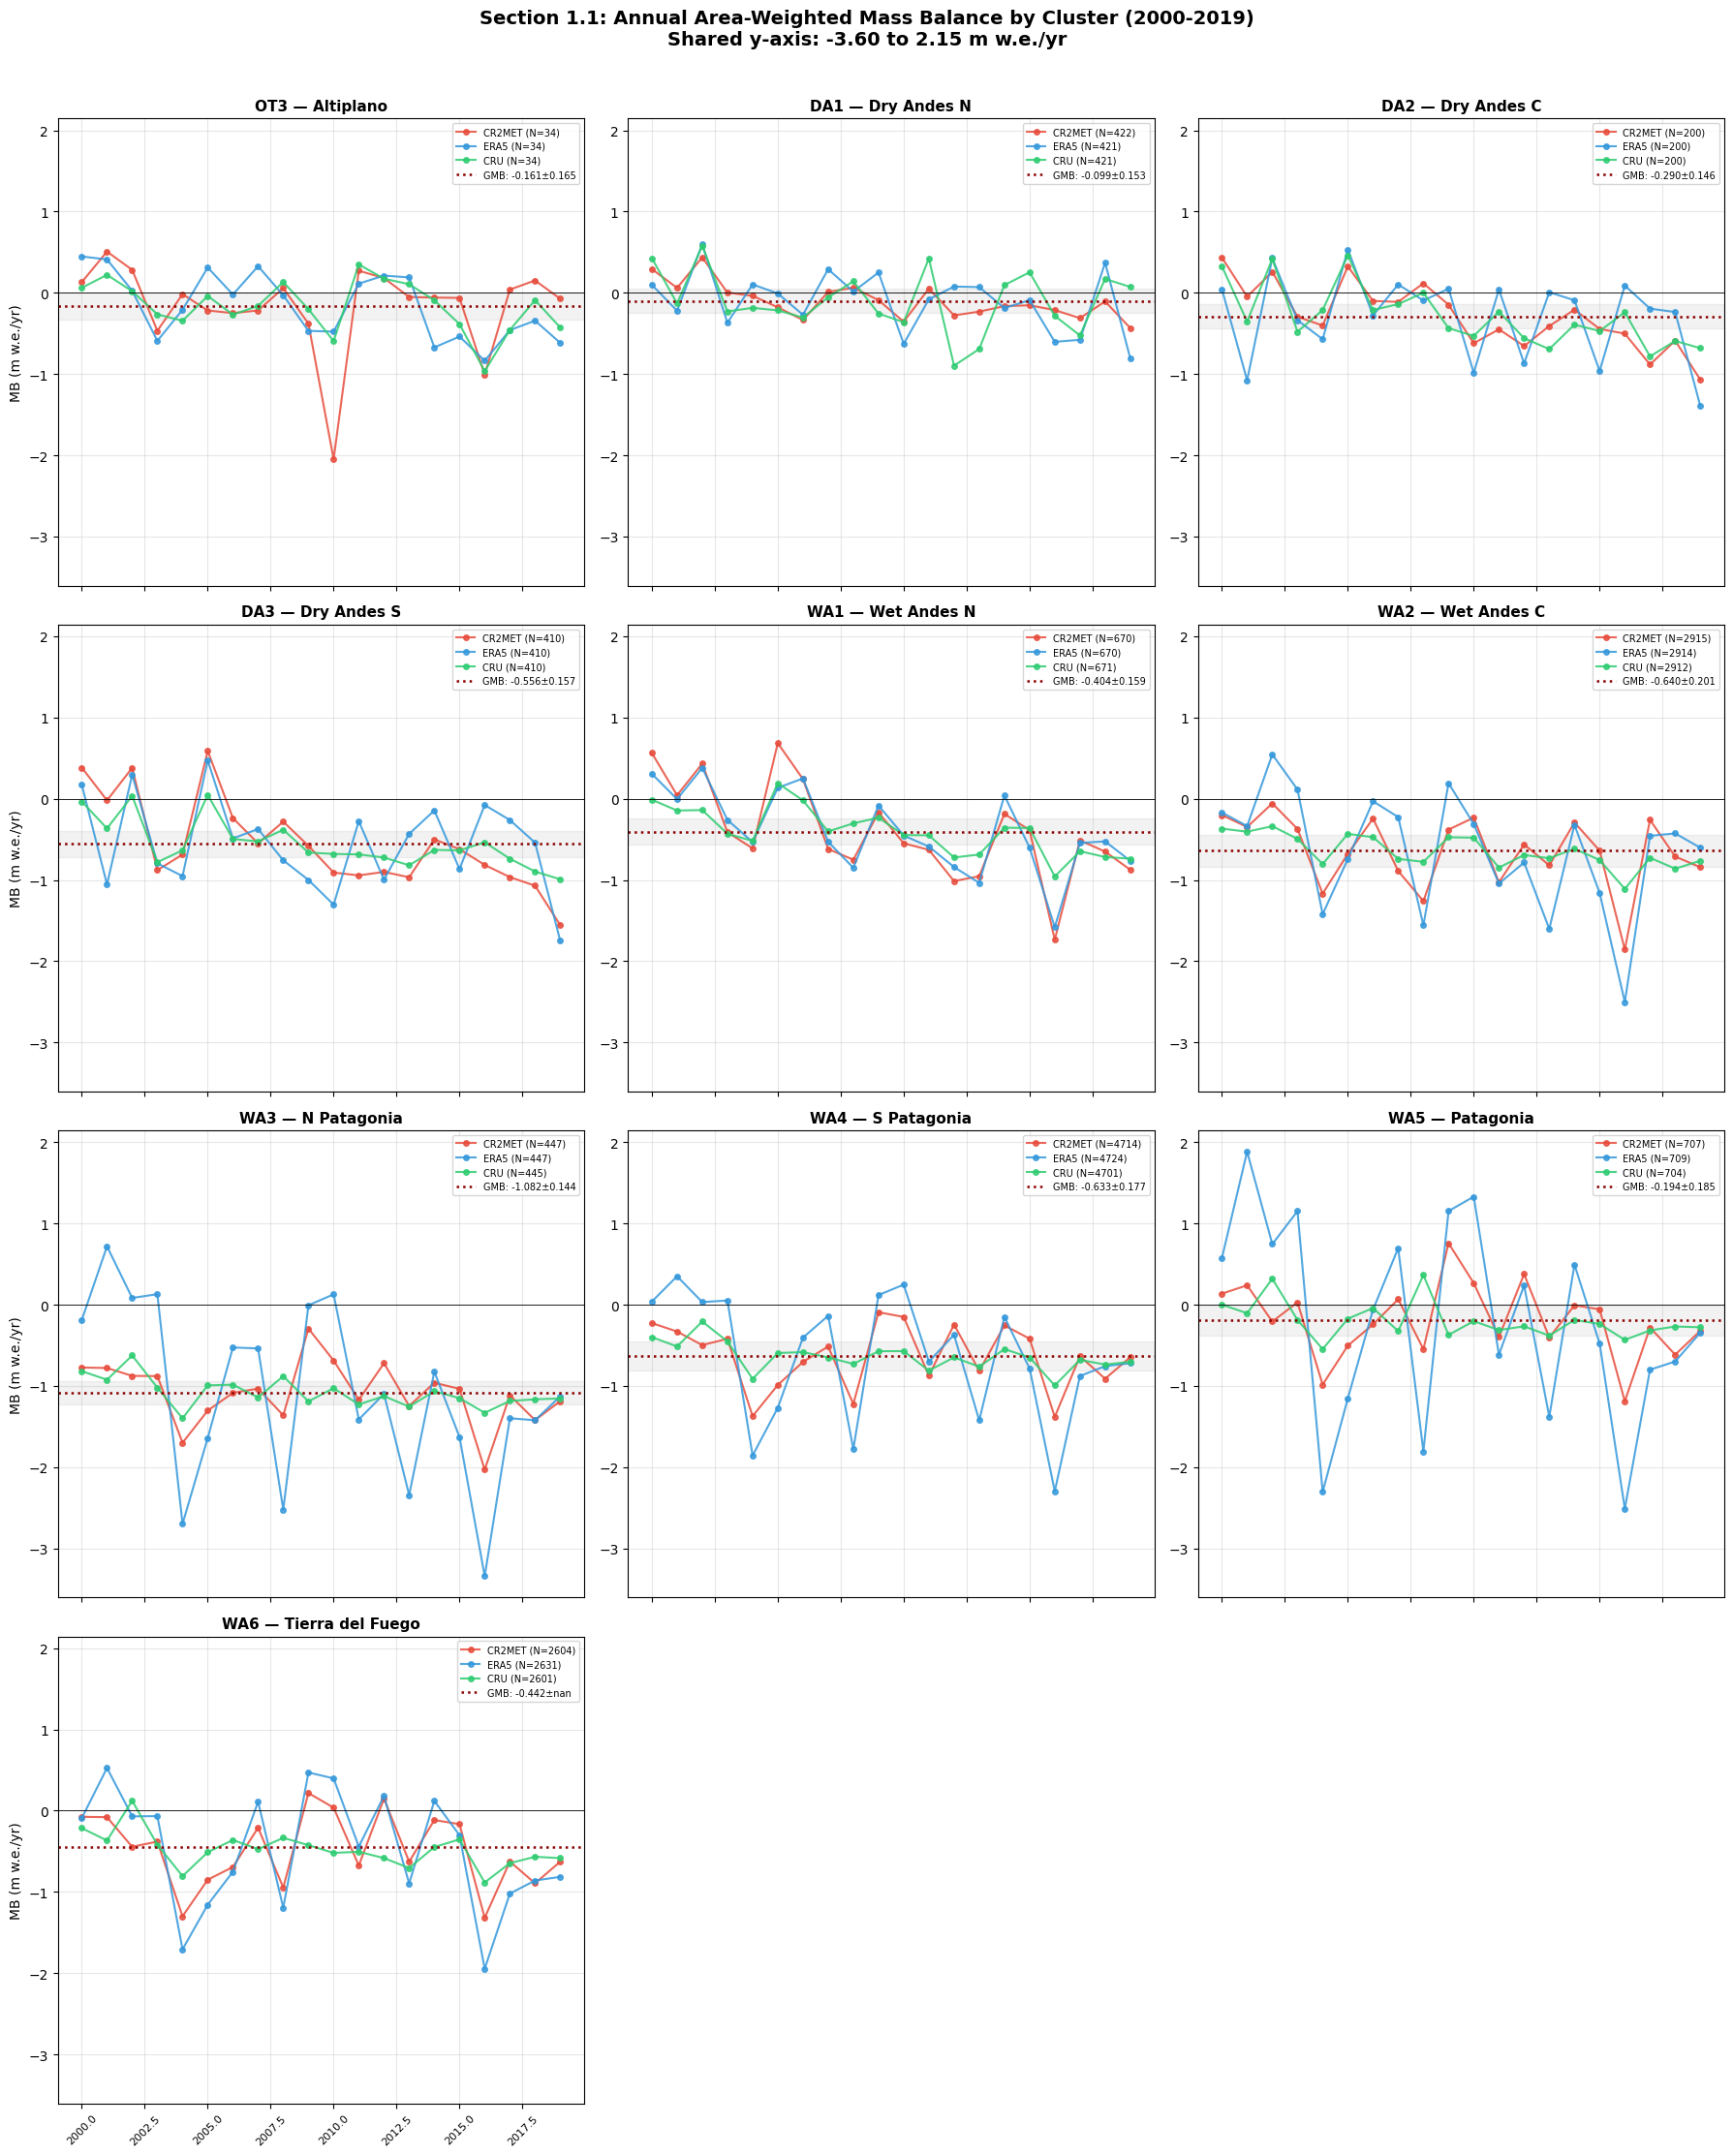

In [47]:
# Annual area-weighted MB timeseries, all clusters, all datasets (shared y-axis)

# ── First pass: compute all timeseries + determine which clusters have data
MB_ANNUAL = {}
CLUSTER_GMB = {}
CLUSTERS_WITH_DATA = []

for cl in CLUSTERS:
    MB_ANNUAL[cl] = {}
    cl_matched_all = glacier_lists[cl]['with_gmb']
    if not cl_matched_all or geodetic_ref is None:
        continue

    cl_weights = geodetic_ref.loc[cl_matched_all, 'area']
    cl_gmb = np.average(geodetic_ref.loc[cl_matched_all, 'dmdtda'] * 1000,
                        weights=cl_weights) / 1000
    cl_gmb_err = np.average(geodetic_ref.loc[cl_matched_all, 'err_dmdtda'] * 1000,
                            weights=cl_weights) / 1000
    CLUSTER_GMB[cl] = (cl_gmb, cl_gmb_err)

    for dataset in datasets:
        mb_file = f'{base_path}{dataset}/{cl}/mb.csv'
        if not os.path.exists(mb_file):
            continue
        mb_df = pd.read_csv(mb_file).set_index('rgi_id')
        year_cols = mb_df.columns[:20]
        matched = [g for g in cl_matched_all if g in mb_df.index]
        if not matched:
            continue
        weights = geodetic_ref.loc[matched, 'area'].values
        annual_mb = [np.average(mb_df.loc[matched, c].values, weights=weights)
                     for c in year_cols]
        ts = pd.DataFrame({'year': range(2000, 2020),
                           'mb': np.array(annual_mb) / 1000})
        MB_ANNUAL[cl][dataset] = ts

    if MB_ANNUAL[cl]:
        CLUSTERS_WITH_DATA.append(cl)

excluded_clusters = [cl for cl in CLUSTERS if cl not in CLUSTERS_WITH_DATA]
if excluded_clusters:
    print(f'Clusters excluded (no MB data): {excluded_clusters}')

# ── Compute global y-limits across all clusters with data ─────────────────
global_min, global_max = np.inf, -np.inf
for cl in CLUSTERS_WITH_DATA:
    for ts in MB_ANNUAL[cl].values():
        global_min = min(global_min, ts['mb'].min())
        global_max = max(global_max, ts['mb'].max())
    cl_gmb, cl_gmb_err = CLUSTER_GMB[cl]
    global_min = min(global_min, cl_gmb - cl_gmb_err)
    global_max = max(global_max, cl_gmb + cl_gmb_err)

y_range = global_max - global_min
YLIM = (global_min - 0.05*y_range, global_max + 0.05*y_range)

# ── Second pass: plot 3x3 grid (only clusters with data), shared y-axis ───
n_clusters = len(CLUSTERS_WITH_DATA)
ncols = 3
nrows = int(np.ceil(n_clusters / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5.5*nrows), sharex=True)
axes_flat = axes.flatten()

for ax, cl in zip(axes_flat, CLUSTERS_WITH_DATA):
    cl_gmb, cl_gmb_err = CLUSTER_GMB[cl]
    for dataset in datasets:
        if dataset not in MB_ANNUAL[cl]:
            continue
        ts = MB_ANNUAL[cl][dataset]
        mb_file = f'{base_path}{dataset}/{cl}/mb.csv'
        mb_df = pd.read_csv(mb_file).set_index('rgi_id')
        matched = [g for g in glacier_lists[cl]['with_gmb'] if g in mb_df.index]
        ax.plot(ts['year'], ts['mb'], 'o-', color=colors[dataset],
                lw=1.5, ms=4, label=f'{dataset} (N={len(matched)})', alpha=0.85)

    ax.axhline(cl_gmb, color='darkred', ls=':', lw=1.8,
              label=f'GMB: {cl_gmb:.3f}±{cl_gmb_err:.3f}')
    ax.axhspan(cl_gmb-cl_gmb_err, cl_gmb+cl_gmb_err, color='gray', alpha=0.1)
    ax.axhline(0, color='k', lw=0.6)
    ax.set_ylim(YLIM)
    ax.set_title(f'{cl} — {REGION_LABELS[cl]}', fontsize=11, fontweight='bold')
    ax.tick_params(labelsize=8, axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc='best')

# Hide unused panels (if n_clusters doesn't fill the grid exactly)
for ax in axes_flat[n_clusters:]:
    ax.set_visible(False)

for i in range(0, n_clusters, ncols):
    axes_flat[i].set_ylabel('MB (m w.e./yr)', fontsize=10)

fig.suptitle('Section 1.1: Annual Area-Weighted Mass Balance by Cluster (2000-2019)\n'
             f'Shared y-axis: {YLIM[0]:.2f} to {YLIM[1]:.2f} m w.e./yr'
             + (f'  |  Excluded: {", ".join(excluded_clusters)} (no data)'
                if excluded_clusters else ''),
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section1_1_mb_timeseries_all_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [48]:
mb_summary_records = []
for cl in CLUSTERS_WITH_DATA:
    for ds_name in datasets:
        if ds_name not in MB_ANNUAL[cl]:
            continue
        ts = MB_ANNUAL[cl][ds_name]
        base_vals = ts[ts['year'].isin(BASELINE)]['mb']
        dr_ts     = ts[ts['year'].isin(range(2010,2020))]
        dr_vals   = dr_ts['mb']
        base_mb, dr_mb = base_vals.mean(), dr_vals.mean()

        # Period comparison — SWITCHED to standard t-test
        t_stat, p_period = stats.ttest_ind(dr_vals, base_vals)

        # Full 20-year trend
        slope_full, _, _, p_trend_full, _ = linregress(ts['year'], ts['mb'])

        # NEW: post-2010-only trend (is MB still declining DURING 2010-2019?)
        if len(dr_ts) >= 4:
            slope_post, _, _, p_trend_post, _ = linregress(dr_ts['year'], dr_ts['mb'])
        else:
            slope_post, p_trend_post = np.nan, np.nan

        mb_summary_records.append({
            'cluster': cl, 'dataset': ds_name,
            'mb_2000_2009': base_mb, 'mb_2010_2019': dr_mb,
            'mb_change': dr_mb - base_mb,
            'period_p': p_period, 'period_sig': sig_stars(p_period),
            'trend_full_slope': slope_full, 'trend_full_p': p_trend_full,
            'trend_full_sig': sig_stars(p_trend_full),
            'trend_post2010_slope': slope_post, 'trend_post2010_p': p_trend_post,
            'trend_post2010_sig': sig_stars(p_trend_post),
        })

df_mb_summary = pd.DataFrame(mb_summary_records)
df_mb_summary.to_csv(f'{OUT_DIR}/section1_2_mb_summary_stats.csv', index=False)

print('Section 1.2: MB trend significance — full record vs. post-2010-only')
print('='*100)
print(f'{"Cluster":6s} {"Dataset":8s} {"Full trend p":13s} {"sig":4s}  '
      f'{"Post-2010 trend p":18s} {"sig"}')
print('-'*100)
for _, row in df_mb_summary.iterrows():
    print(f'{row["cluster"]:6s} {row["dataset"]:8s} '
          f'{row["trend_full_p"]:13.4f} {row["trend_full_sig"]:4s}  '
          f'{row["trend_post2010_p"]:18.4f} {row["trend_post2010_sig"]}')

print('Section 1.2b: Period comparison (t-test), 2000-2009 vs 2010-2019 means')
print('='*80)
print(f'{"Cluster":6s} {"Dataset":8s} {"2000-09":9s} {"2010-19":9s} '
      f'{"Change":8s} {"period_p":9s} {"sig"}')
print('-'*80)
for _, row in df_mb_summary.iterrows():
    print(f'{row["cluster"]:6s} {row["dataset"]:8s} '
          f'{row["mb_2000_2009"]:9.3f} {row["mb_2010_2019"]:9.3f} '
          f'{row["mb_change"]:+8.3f} {row["period_p"]:9.4f} {row["period_sig"]}')

Section 1.2: MB trend significance — full record vs. post-2010-only
Cluster Dataset  Full trend p  sig   Post-2010 trend p  sig
----------------------------------------------------------------------------------------------------
OT3    CR2MET          0.5549 ns                0.3350 ns
OT3    ERA5            0.0054 **                0.1240 ns
OT3    CRU             0.0942 ns                0.2820 ns
DA1    CR2MET          0.0012 **                0.4777 ns
DA1    ERA5            0.0951 ns                0.6298 ns
DA1    CRU             0.3846 ns                0.5339 ns
DA2    CR2MET          0.0000 ***               0.1450 ns
DA2    ERA5            0.2733 ns                0.7858 ns
DA2    CRU             0.0010 ***               0.2974 ns
DA3    CR2MET          0.0001 ***               0.2050 ns
DA3    ERA5            0.2624 ns                0.8664 ns
DA3    CRU             0.0006 ***               0.1646 ns
WA1    CR2MET          0.0018 **                0.7142 ns
WA1    ERA5      

Mass balance showed a statistically significant declining trend over the full 2000 to 2019 record in seven of ten clusters. Two clusters, OT3 and WA5, showed no significant decline on any test in any dataset. The most robust evidence was in WA1, significant across all three climate datasets on both the full trend and the period comparison. DA2 and DA3 showed significant decline in CR2MET and CRU but not ERA5, on both tests. DA1 showed significant decline only in CR2MET, with ERA5 and CRU both non-significant on both tests. WA2, WA3, WA4, and WA6 each showed significant decline in at most one dataset, most consistently CRU, and results were generally weaker and less consistent than in the Central Andes or WA1. This pattern is broadly consistent with the Central Chilean Megadrought, which affected the central and north-central Andes most severely from roughly 2010 to 2019.

When the trend analysis was restricted to 2010 to 2019 alone, no cluster showed a statistically significant within decade trend in any dataset, including WA5. A direct two sample t test comparing mean mass balance between the two periods, 2000 to 2009 versus 2010 to 2019, confirmed a statistically significant shift in the same clusters that showed full record trend significance, with the exception that DA1's period-test significance did not hold up in ERA5. Together, these results indicate that mass balance shifted to a significantly more negative mean state during the drought decade relative to the preceding decade in most Central Andes and Wet Andes North clusters, but the data do not provide statistical evidence of continued progressive decline within the drought period itself. This distinction is consistent with, though not confirmed by, prior findings of a shift from near equilibrium to significant mass loss in the extratropical Andes around 2009 (Dussaillant et al., 2019).

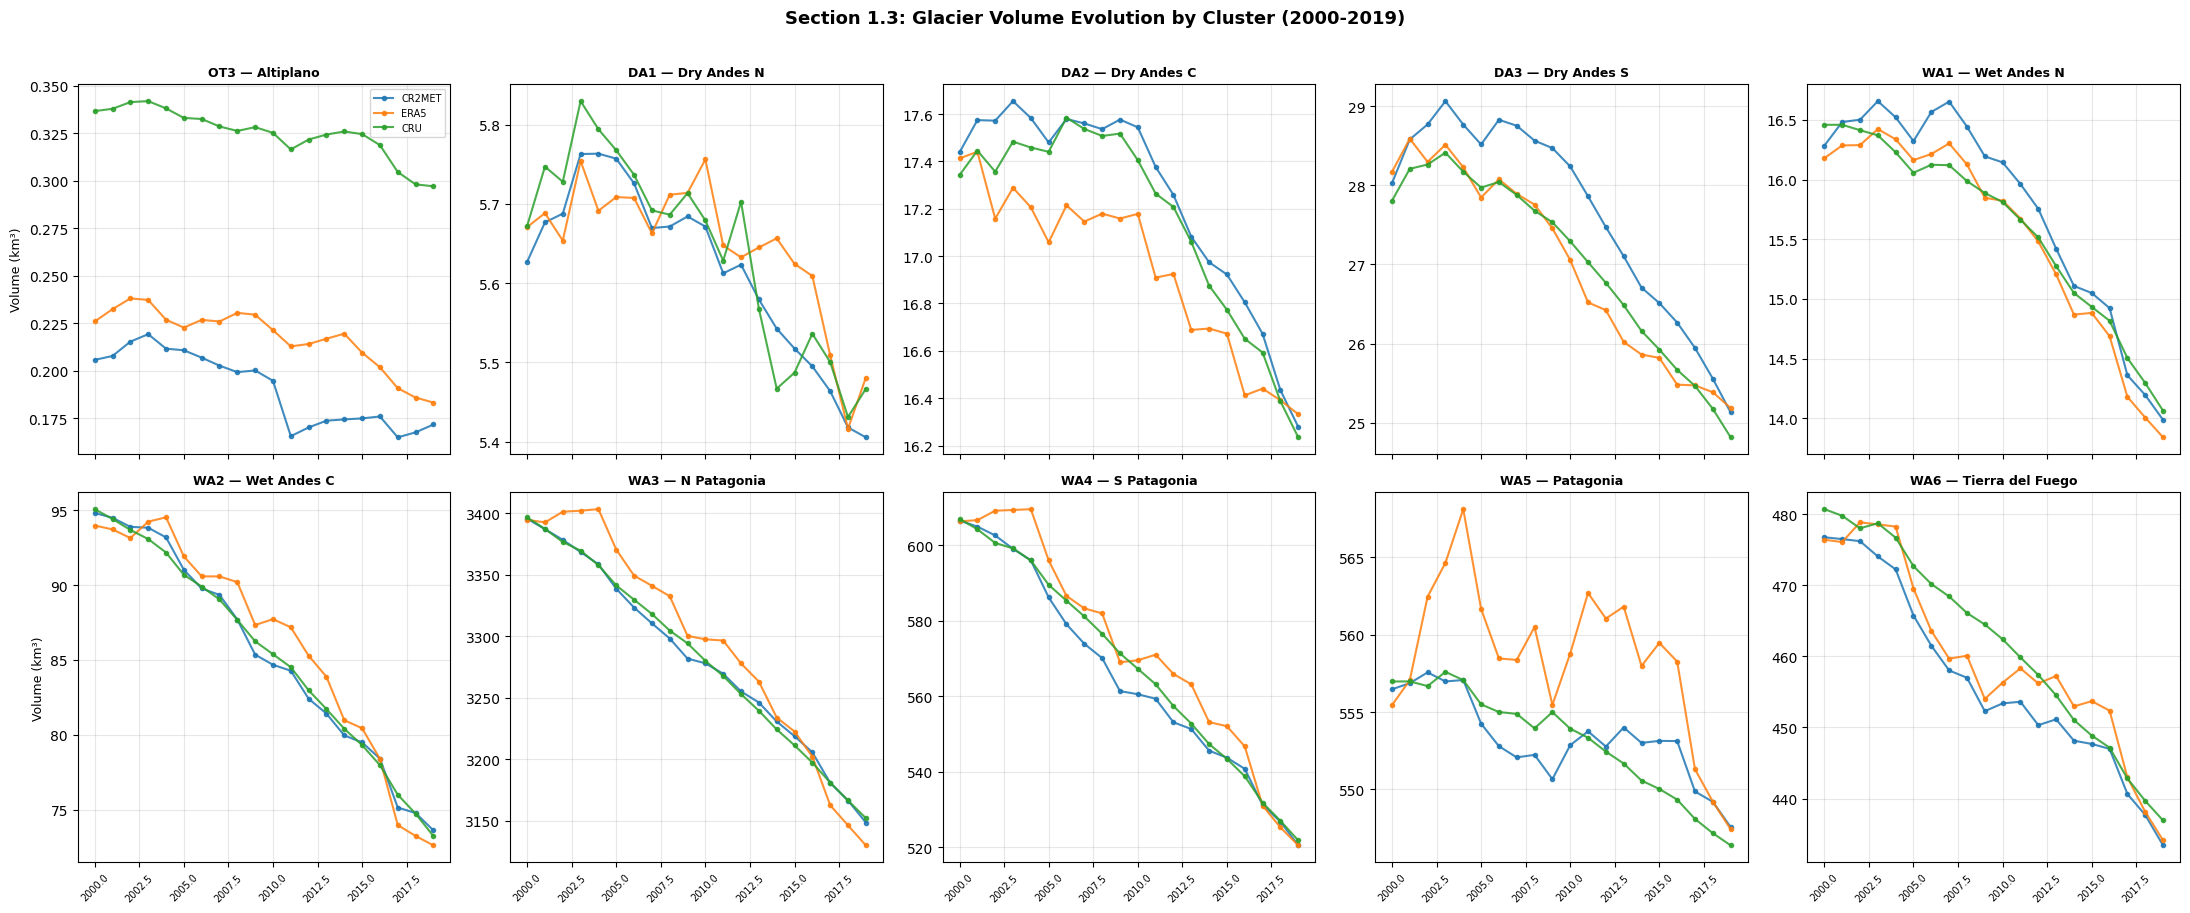

In [49]:
# Glacier volume evolution, all clusters, all datasets
def load_cluster_totals(cluster, dataset):
    f = nc_path(dataset, cluster)
    if not os.path.exists(f):
        return None
    ds = xr.open_dataset(f)
    vol = ds['volume'].sum(dim='rgi_id').values / 1e9
    years = ds['time'].values
    ds.close()
    return pd.DataFrame({'year': years, 'volume_km3': vol})

fig, axes = plt.subplots(2, 5, figsize=(22, 9), sharex=True)
axes_flat = axes.flatten()
VOLUME_TOTALS = {}

for ax, cl in zip(axes_flat, CLUSTERS):
    VOLUME_TOTALS[cl] = {}
    for ds_name in datasets:
        ts = load_cluster_totals(cl, ds_name)
        if ts is None:
            continue
        ts = ts[ts['year'].isin(YEARS)]  # trim to 2000-2019
        VOLUME_TOTALS[cl][ds_name] = ts
        ax.plot(ts['year'], ts['volume_km3'], 'o-', color=DS_COLORS[ds_name],
                lw=1.5, ms=3, label=ds_name, alpha=0.85)
    ax.set_title(f'{cl} — {REGION_LABELS[cl]}', fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7, axis='x', rotation=45)
    ax.grid(True, alpha=0.3)

axes_flat[0].legend(fontsize=7, loc='best')
axes_flat[0].set_ylabel('Volume (km³)', fontsize=9)
axes_flat[5].set_ylabel('Volume (km³)', fontsize=9)
fig.suptitle('Section 1.3: Glacier Volume Evolution by Cluster (2000-2019)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section1_3_volume_evolution_all_clusters.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [50]:
# Volume change summary stats (% change, trend, significance)
vol_summary_records = []
for cl in CLUSTERS:
    for ds_name in datasets:
        if cl not in VOLUME_TOTALS or ds_name not in VOLUME_TOTALS[cl]:
            continue
        ts = VOLUME_TOTALS[cl][ds_name]
        if len(ts) < 5:
            continue
        v0, v1 = ts.iloc[0]['volume_km3'], ts.iloc[-1]['volume_km3']
        pct_change = (v1 - v0) / v0 * 100 if v0 != 0 else np.nan
        slope, intercept, r, p, se = linregress(ts['year'], ts['volume_km3'])
        vol_summary_records.append({
            'cluster': cl, 'dataset': ds_name,
            'volume_2000_km3': v0, 'volume_2019_km3': v1,
            'pct_change': pct_change,
            'trend_km3_per_yr': slope, 'trend_p': p, 'trend_sig': sig_stars(p),
        })

df_vol_summary = pd.DataFrame(vol_summary_records)
df_vol_summary.to_csv(f'{OUT_DIR}/section1_4_volume_summary_stats.csv', index=False)

print('Section 1.4: Volume change summary by cluster and dataset')
print('='*95)
print(f'{"Cluster":6s} {"Dataset":8s} {"Vol 2000":9s} {"Vol 2019":9s} '
      f'{"% chg":8s} {"Trend km³/yr":13s} {"p":8s} {"sig"}')
print('-'*95)
for _, row in df_vol_summary.iterrows():
    print(f'{row["cluster"]:6s} {row["dataset"]:8s} '
          f'{row["volume_2000_km3"]:9.2f} {row["volume_2019_km3"]:9.2f} '
          f'{row["pct_change"]:+7.1f}% {row["trend_km3_per_yr"]:13.4f} '
          f'{row["trend_p"]:8.4f} {row["trend_sig"]}')

Section 1.4: Volume change summary by cluster and dataset
Cluster Dataset  Vol 2000  Vol 2019  % chg    Trend km³/yr  p        sig
-----------------------------------------------------------------------------------------------
OT3    CR2MET        0.21      0.17   -16.5%       -0.0029   0.0000 ***
OT3    ERA5          0.23      0.18   -18.9%       -0.0024   0.0000 ***
OT3    CRU           0.34      0.30   -11.8%       -0.0020   0.0000 ***
DA1    CR2MET        5.63      5.41    -3.9%       -0.0162   0.0000 ***
DA1    ERA5          5.67      5.48    -3.4%       -0.0107   0.0003 ***
DA1    CRU           5.67      5.47    -3.6%       -0.0180   0.0000 ***
DA2    CR2MET       17.44     16.28    -6.6%       -0.0626   0.0000 ***
DA2    ERA5         17.41     16.33    -6.2%       -0.0566   0.0000 ***
DA2    CRU          17.34     16.23    -6.4%       -0.0602   0.0000 ***
DA3    CR2MET       28.03     25.13   -10.3%       -0.1857   0.0000 ***
DA3    ERA5         28.17     25.19   -10.6%       -0

Glacier volume declined significantly in every cluster and every climate dataset over 2000 to 2019, with relative losses ranging from about 1.4 to 1.9 percent in WA5 to 22.4 to 23.0 percent in WA2. Unlike the annual mass balance trend, which was sensitive to climate forcing choice in several clusters, cumulative volume loss showed strong agreement across CR2MET, ERA5, and CRU in both magnitude and direction, indicating that the relative rate of glacier volume decline is a robust finding largely independent of climate dataset choice.

In [54]:
# Accumulation vs. ablation decomposition (why is MB changing?)
accum_ablat_records = []
for ds_name in datasets:
    for cl in CLUSTERS:
        f = nc_path(ds_name, cl)
        if not os.path.exists(f):
            continue
        ds = xr.open_dataset(f)
        rgi_all = list(ds.rgi_id.values)
        actual_years = ds['time'].values.astype(int).tolist()

        snow_annual = np.nansum(ds['snowfall_on_glacier_monthly'].values,
                                axis=1) / WATER_DENSITY
        melt_annual = np.nansum(ds['melt_on_glacier_monthly'].values,
                                axis=1) / WATER_DENSITY
        ds.close()

        for gauge_id in basins_in_cluster(cl):
            info = GAUGE_INFO_FRAC[gauge_id]
            rgi_ids = info.get('rgi_ids', [])
            mask_ids = [r for r in rgi_ids if r in rgi_all]
            if not mask_ids:
                continue
            mask = np.isin(rgi_all, mask_ids)
            basin_snow = snow_annual[:, mask].sum(axis=1)
            basin_melt = melt_annual[:, mask].sum(axis=1)

            ann = pd.DataFrame({'year': actual_years, 'snow_m3': basin_snow,
                                'melt_m3': basin_melt})
            base = ann[ann['year'].isin(BASELINE)]
            drgt = ann[ann['year'].isin(range(2010, 2020))]
            if len(base) == 0 or len(drgt) == 0:
                continue

            snow_base, melt_base = base['snow_m3'].mean(), base['melt_m3'].mean()
            snow_dr, melt_dr     = drgt['snow_m3'].mean(), drgt['melt_m3'].mean()
            mb_base, mb_dr = snow_base - melt_base, snow_dr - melt_dr
            delta = mb_dr - mb_base
            if abs(delta) < 1e-6:
                continue

            mb_cf_snow = snow_dr   - melt_base
            mb_cf_melt = snow_base - melt_dr
            pct_accum = (mb_cf_snow - mb_base) / delta * 100
            pct_ablat = (mb_cf_melt - mb_base) / delta * 100

            accum_ablat_records.append({
                'gauge_id': gauge_id, 'cluster': cl, 'dataset': ds_name,
                'snow_chg_pct': (snow_dr-snow_base)/snow_base*100 if snow_base>0 else np.nan,
                'melt_chg_pct': (melt_dr-melt_base)/melt_base*100 if melt_base>0 else np.nan,
                'delta_mb_m3': delta,
                'pct_accum_driven': np.clip(pct_accum, -200, 200),
                'pct_ablat_driven': np.clip(pct_ablat, -200, 200),
            })

df_mb_decomp = pd.DataFrame(accum_ablat_records)
df_mb_decomp.to_csv(f'{OUT_DIR}/section1_5_mb_decomposition.csv', index=False)

print('Section 1.5: MB change decomposition — accumulation vs. ablation driven')
print('(worsening-MB basins only, i.e. delta_mb < 0; median across basins)')
print('='*90)
print(f'{"Cluster":6s} {"Dataset":8s} {"n":4s} {"Snow Δ%":9s} {"Melt Δ%":9s}  '
      f'{"% accum-driven":15s} {"% ablat-driven"}')
print('-'*90)
for cl in CLUSTERS:
    for ds_name in datasets:
        sub = df_mb_decomp[(df_mb_decomp['cluster']==cl) &
                           (df_mb_decomp['dataset']==ds_name) &
                           (df_mb_decomp['delta_mb_m3']<0)]
        if len(sub) == 0:
            continue
        print(f'{cl:6s} {ds_name:8s} {len(sub):4d} '
              f'{sub["snow_chg_pct"].median():+8.1f}% '
              f'{sub["melt_chg_pct"].median():+8.1f}%  '
              f'{sub["pct_accum_driven"].median():14.1f}%  '
              f'{sub["pct_ablat_driven"].median():14.1f}%')

print('\nSection 1 complete — proceed to Section 1.5 (lag detection)')

Section 1.5: MB change decomposition — accumulation vs. ablation driven
(worsening-MB basins only, i.e. delta_mb < 0; median across basins)
Cluster Dataset  n    Snow Δ%   Melt Δ%    % accum-driven  % ablat-driven
------------------------------------------------------------------------------------------
OT3    CR2MET      2     -8.1%    +12.0%            54.4%            45.6%
OT3    ERA5        2     -4.8%    +33.0%            19.2%            80.8%
OT3    CRU         2     -8.7%    +59.0%            13.7%            86.3%
DA1    CR2MET     21     -9.3%    +48.0%            16.0%            84.0%
DA1    ERA5       21     -0.6%    +57.5%             1.1%            98.9%
DA1    CRU        21     -6.6%    +40.7%            16.1%            83.9%
DA2    CR2MET     14    -44.9%    +23.5%            65.9%            34.1%
DA2    ERA5       14    -27.2%     +6.4%            80.0%            20.0%
DA2    CRU        14    -39.3%    +22.3%            53.4%            46.6%
DA3    CR2MET     16

In [55]:
# Lag detection (feeds Section 2)
def deseasonalize(series, months):
    anom = series.copy().astype(float)
    for mo in range(1, 13):
        mask = months == mo
        if mask.sum() > 0:
            anom[mask] -= anom[mask].mean()
    return anom

def best_lag_pearson(x, y, max_lag=6):
    best_r, best_lag = 0, 0
    for lag in range(0, max_lag + 1):
        if lag == 0:
            valid = ~(np.isnan(x) | np.isnan(y))
            if valid.sum() < 10:
                continue
            r, _ = stats.pearsonr(x[valid], y[valid])
        else:
            xlag, ylag = x[:-lag], y[lag:]
            valid = ~(np.isnan(xlag) | np.isnan(ylag))
            if valid.sum() < 10:
                continue
            r, _ = stats.pearsonr(xlag[valid], ylag[valid])
        if abs(r) > abs(best_r):
            best_r, best_lag = r, lag
    return best_lag, best_r

print('Section 1.5: Deseasonalized lag detection by cluster (CR2MET)')
print('='*70)
print(f'{"Cluster":6s} {"n":4s} {"Raw median":11s} {"Deseas median":13s} {"Interpretation"}')
print('-'*70)

DESEAS_LAG = {}
for cl in CLUSTERS:
    cl_gauges = basins_in_cluster(cl)
    cl_raw, cl_des = [], []
    for gauge_id in cl_gauges:
        res = RESULTS['CR2MET'].get(gauge_id)
        if res is None:
            continue
        m  = res['monthly']
        cy = GAUGE_INFO_FRAC[gauge_id].get('complete_years', YEARS)
        mc = (m[m['year'].isin(cy)].sort_values(['year','month'])
              .dropna(subset=['q_m3_mon']).reset_index(drop=True))
        if len(mc) < 36:
            continue
        glac   = mc['glacier_runoff_m3'].values.astype(float)
        q      = mc['q_m3_mon'].values.astype(float)
        months = mc['month'].values
        lag_r, _ = best_lag_pearson(glac, q)
        lag_d, _ = best_lag_pearson(deseasonalize(glac, months),
                                    deseasonalize(q, months))
        cl_raw.append(lag_r)
        cl_des.append(lag_d)

    if not cl_raw:
        DESEAS_LAG[cl] = 0
        continue
    med_r, med_d = np.median(cl_raw), np.median(cl_des)
    lag_final = int(round(med_d))
    DESEAS_LAG[cl] = lag_final
    interp = ('ALIASING — raw lag not used' if med_d < med_r - 1
             else f'Genuine {lag_final}-month delay applied')
    print(f'{cl:6s} {len(cl_raw):4d} {med_r:11.1f} {med_d:13.1f} {interp}')

print(f'\nDESEAS_LAG dict (applied to all Section 2 calcs): {DESEAS_LAG}')
print('Section 1.5 complete — proceed to Section 2 (Q2), lag-corrected')

Section 1.5: Deseasonalized lag detection by cluster (CR2MET)
Cluster n    Raw median  Deseas median Interpretation
----------------------------------------------------------------------
OT3       2         1.5           0.5 Genuine 0-month delay applied
DA1      21         2.0           0.0 ALIASING — raw lag not used
DA2      14         1.5           1.0 Genuine 1-month delay applied
DA3      16         2.0           0.0 ALIASING — raw lag not used
WA1      50         5.5           0.0 ALIASING — raw lag not used
WA2      34         1.0           1.0 Genuine 1-month delay applied
WA3       7         2.0           1.0 Genuine 1-month delay applied
WA4      22         1.0           1.0 Genuine 1-month delay applied
WA6      10         1.0           1.0 Genuine 1-month delay applied

DESEAS_LAG dict (applied to all Section 2 calcs): {'OT3': 0, 'DA1': 0, 'DA2': 1, 'DA3': 0, 'WA1': 0, 'WA2': 1, 'WA3': 1, 'WA4': 1, 'WA5': 0, 'WA6': 1}
Section 1.5 complete — proceed to Section 2 (Q2), lag-c

"Aliasing" here means the raw cross correlation was picking up a fake lag caused by the fact that both glacier melt and streamflow follow the same annual seasonal cycle, melt peaks in summer, streamflow peaks in summer, so a naive correlation between them can show a spurious multi month "lag" just because shifting one series by a few months still lines its seasonal bump up reasonably well with the other series' bump from a different year, not because there's a real physical delay. The deseasonalizing step subtracts each month's own long term average before correlating, which removes that shared seasonal shape and leaves only the genuine month to month covariation. How we know it's aliasing rather than a real lag: the diagnostic is comparing the raw lag versus the deseasonalized lag, and whenever the deseasonalized lag collapses to 0 while the raw lag was large (WA1: 5.5 down to 0.0, DA1: 2.0 down to 0.0, DA3: 2.0 down to 0.0), that's the signature of aliasing, the "lag" only existed because of shared seasonality, and vanishes once that's removed. Clusters where the deseasonalized lag stays close to the raw lag (DA2: 1.5 to 1.0, WA2 through WA6: values staying around 1.0) are showing a genuine, physically real routing delay that survives deseasonalizing.

In [82]:
# Section 1.5b (build): Climate driver anomalies by cluster

def load_camels_mon_full(fname):
    df = pd.read_csv(f'{CAMELS_FULL}/{fname}')
    df = df[(df['year']>=2000)&(df['year']<=2019)].copy()
    gauge_cols = [c for c in df.columns if c not in ['date','year','month','day']]
    return df[['year','month']+gauge_cols]

precip_clim = load_camels_mon_full('precip_cr2met_mm_mon.csv')
tmean_clim  = load_camels_mon_full('tmean_cr2met_C_mon.csv')
pet_clim    = load_camels_mon_full('pet_hargreaves_mm_mon.csv')

clim_records = []
for cl in CLUSTERS:
    gauges = [g for g in basins_in_cluster(cl) if g in precip_clim.columns]
    if not gauges:
        continue
    for year in YEARS:
        p_ann = precip_clim[precip_clim['year']==year][gauges].sum().mean()
        t_ann = tmean_clim[tmean_clim['year']==year][gauges].mean().mean()
        e_ann = pet_clim[pet_clim['year']==year][gauges].sum().mean()
        clim_records.append({'cluster': cl, 'year': year,
                             'precip_ann': p_ann, 'tmean_ann': t_ann, 'pet_ann': e_ann})

df_clim = pd.DataFrame(clim_records)
baseline_means = (df_clim[df_clim['year'].isin(BASELINE)]
                  .groupby('cluster')[['precip_ann','tmean_ann','pet_ann']]
                  .mean().rename(columns=lambda c: c+'_base'))
df_clim = df_clim.merge(baseline_means, on='cluster', how='left')
df_clim['precip_anom_pct'] = (df_clim['precip_ann']-df_clim['precip_ann_base'])/df_clim['precip_ann_base']*100
df_clim['tmean_anom']      = df_clim['tmean_ann']-df_clim['tmean_ann_base']
df_clim['pet_anom_pct']    = (df_clim['pet_ann']-df_clim['pet_ann_base'])/df_clim['pet_ann_base']*100

print(f'df_clim built: {df_clim.shape}')

df_clim built: (180, 11)


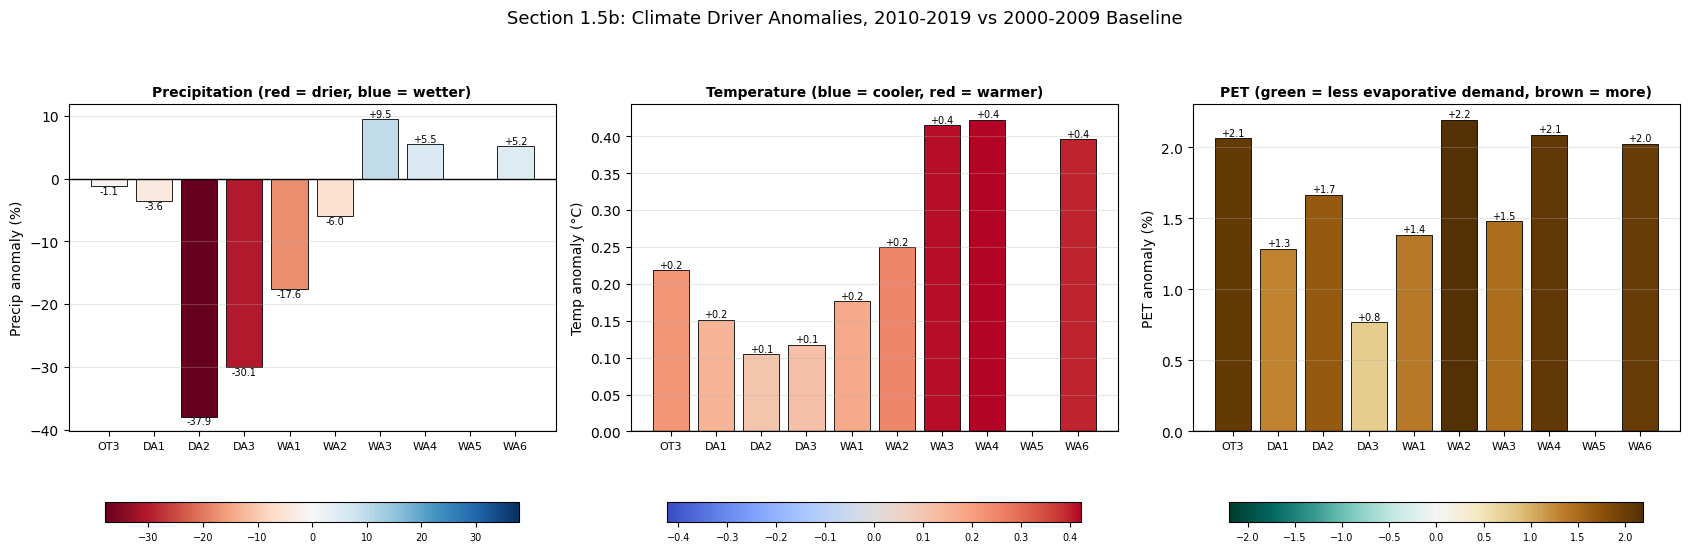

In [83]:
# Section 1.5b (plot): Climate driver anomalies figure

from matplotlib.colors import TwoSlopeNorm
from matplotlib.cm import ScalarMappable

drought_yrs = range(2010, 2020)

var_config = {
    'precip_anom_pct': {'label': 'Precip anomaly (%)', 'cmap': 'RdBu',
                        'title': 'Precipitation (red = drier, blue = wetter)'},
    'tmean_anom': {'label': 'Temp anomaly (°C)', 'cmap': 'coolwarm',
                  'title': 'Temperature (blue = cooler, red = warmer)'},
    'pet_anom_pct': {'label': 'PET anomaly (%)', 'cmap': 'BrBG_r',
                     'title': 'PET (green = less evaporative demand, brown = more)'},
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (var, cfg) in zip(axes, var_config.items()):
    vals = [df_clim[(df_clim['cluster']==cl)&(df_clim['year'].isin(drought_yrs))][var].mean()
            for cl in CLUSTERS]
    vmax_abs = max(abs(min(vals)), abs(max(vals)))
    norm = TwoSlopeNorm(vmin=-vmax_abs, vcenter=0, vmax=vmax_abs)
    cmap = plt.get_cmap(cfg['cmap'])
    bar_colors = [cmap(norm(v)) for v in vals]

    bars = ax.bar(CLUSTERS, vals, color=bar_colors, edgecolor='k', lw=0.6)
    ax.axhline(0, color='k', lw=1)
    for bar, v in zip(bars, vals):
        va = 'bottom' if v >= 0 else 'top'
        ax.text(bar.get_x()+bar.get_width()/2, v, f'{v:+.1f}', ha='center', va=va, fontsize=7)

    ax.set_ylabel(cfg['label'], fontsize=10)
    ax.set_title(cfg['title'], fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(True, alpha=0.3, axis='y')
    sm = ScalarMappable(cmap=cmap, norm=norm)
    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal', pad=0.15, shrink=0.85)
    cbar.ax.tick_params(labelsize=7)

fig.suptitle('Section 1.5b: Climate Driver Anomalies, 2010-2019 vs 2000-2009 Baseline',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section1_5b_climate_drivers.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 2 — Q2: Glacier contribution to streamflow (lag-corrected)

In [56]:
# Build lag-corrected monthly dataset (used by all of Section 2)
def get_lag_corrected_monthly(gauge_id, ds_name, cluster):
    """Returns monthly df with glac_shifted = glacier_runoff_m3 shifted by
    DESEAS_LAG[cluster] months. lag=0 clusters are returned unshifted."""
    res = RESULTS[ds_name].get(gauge_id)
    if res is None:
        return None
    m = res['monthly'].copy()
    cy = GAUGE_INFO_FRAC[gauge_id].get('complete_years', YEARS)
    m = m[m['year'].isin(cy)].sort_values(['year','month']).reset_index(drop=True)
    lag = DESEAS_LAG.get(cluster, 0)
    m['glac_shifted'] = (m['glacier_runoff_m3'].shift(lag) if lag > 0
                         else m['glacier_runoff_m3'])
    return m

In [58]:
# Compute actual peak glacier-fraction month per cluster, don't assume March

print('Peak glacier contribution month by cluster (CR2MET, mean fraction by month)')
print('='*70)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
PEAK_MONTH = {}

for cl in CLUSTERS:
    gauges_in_cl = basins_in_cluster(cl)
    mon_fracs = []
    for gid in gauges_in_cl:
        m = get_lag_corrected_monthly(gid, 'CR2MET', cl)
        if m is None:
            continue
        mf = m.groupby('month').apply(
            lambda g: g['glac_shifted'].sum() / g['q_m3_mon'].sum()
            if g['q_m3_mon'].sum() > 0 else np.nan)
        mon_fracs.append(mf)
    if not mon_fracs:
        continue
    mean_mf = pd.concat(mon_fracs, axis=1).mean(axis=1)
    peak_month = mean_mf.idxmax()
    PEAK_MONTH[cl] = peak_month
    print(f'{cl:6s} peak month = {month_labels[peak_month-1]:4s} '
          f'({mean_mf[peak_month]*100:.1f}%)  '
          f'| full cycle: ' + '  '.join(f'{month_labels[m-1]}:{mean_mf.get(m,np.nan)*100:.0f}%'
                                        for m in range(1,13)))

print(f'\nPEAK_MONTH dict: {PEAK_MONTH}')

Peak glacier contribution month by cluster (CR2MET, mean fraction by month)
OT3    peak month = Feb  (10.8%)  | full cycle: Jan:7%  Feb:11%  Mar:6%  Apr:0%  May:0%  Jun:0%  Jul:0%  Aug:0%  Sep:0%  Oct:0%  Nov:1%  Dec:7%
DA1    peak month = Jan  (61.4%)  | full cycle: Jan:61%  Feb:47%  Mar:28%  Apr:5%  May:1%  Jun:0%  Jul:0%  Aug:0%  Sep:0%  Oct:1%  Nov:3%  Dec:21%
DA2    peak month = Mar  (45.3%)  | full cycle: Jan:7%  Feb:30%  Mar:45%  Apr:39%  May:10%  Jun:3%  Jul:1%  Aug:1%  Sep:1%  Oct:1%  Nov:1%  Dec:2%
DA3    peak month = Feb  (32.8%)  | full cycle: Jan:14%  Feb:33%  Mar:25%  Apr:16%  May:8%  Jun:2%  Jul:1%  Aug:1%  Sep:2%  Oct:3%  Nov:4%  Dec:6%
WA1    peak month = Feb  (17.7%)  | full cycle: Jan:10%  Feb:18%  Mar:14%  Apr:8%  May:2%  Jun:0%  Jul:0%  Aug:0%  Sep:0%  Oct:1%  Nov:2%  Dec:5%
WA2    peak month = Feb  (11.9%)  | full cycle: Jan:7%  Feb:12%  Mar:11%  Apr:8%  May:4%  Jun:2%  Jul:1%  Aug:0%  Sep:1%  Oct:1%  Nov:4%  Dec:5%
WA3    peak month = Feb  (30.8%)  | full cycle: 

In [60]:
# Peak ABSOLUTE glacier melt month per cluster (not fraction of streamflow)

print('Peak absolute glacier melt month by cluster (CR2MET)')
print('='*70)

PEAK_MELT_MONTH = {}
for cl in CLUSTERS:
    gauges_in_cl = basins_in_cluster(cl)
    mon_melt = []
    for gid in gauges_in_cl:
        res = RESULTS['CR2MET'].get(gid)
        if res is None:
            continue
        m = res['monthly']
        cy = GAUGE_INFO_FRAC[gid].get('complete_years', YEARS)
        m = m[m['year'].isin(cy)]
        mm = m.groupby('month')['melt_on_glacier_m3'].sum()
        mon_melt.append(mm)
    if not mon_melt:
        continue
    total_melt_by_month = pd.concat(mon_melt, axis=1).sum(axis=1)
    peak_month = total_melt_by_month.idxmax()
    PEAK_MELT_MONTH[cl] = peak_month
    print(f'{cl:6s} peak melt month = {month_labels[peak_month-1]:4s}')

print(f'\nPEAK_MELT_MONTH dict: {PEAK_MELT_MONTH}')

Peak absolute glacier melt month by cluster (CR2MET)
OT3    peak melt month = Feb 
DA1    peak melt month = Jan 
DA2    peak melt month = Feb 
DA3    peak melt month = Feb 
WA1    peak melt month = Feb 
WA2    peak melt month = Feb 
WA3    peak melt month = Jan 
WA4    peak melt month = Feb 
WA6    peak melt month = Feb 

PEAK_MELT_MONTH dict: {'OT3': 2, 'DA1': 1, 'DA2': 2, 'DA3': 2, 'WA1': 2, 'WA2': 2, 'WA3': 1, 'WA4': 2, 'WA6': 2}


In [61]:
# National + cluster summary table: annual, FMA, peak month (per-cluster)
# Uses PEAK_MONTH (computed earlier) instead of assuming March everywhere.
# NATIONAL uses February as the representative peak month (matches 7 of 9
# clusters); WA5 has no CAMELS gauges so no basin-level fraction can be
# computed for it here regardless of month, defaults to February to avoid
# crashing but will return no basins/NaN as with all other WA5 rows.

def basin_mean_frac(gauge_id, ds_name, cluster, months=None):
    m = get_lag_corrected_monthly(gauge_id, ds_name, cluster)
    if m is None:
        return np.nan
    if months is not None:
        m = m[m['month'].isin(months)]
    m = m.dropna(subset=['glac_shifted', 'q_m3_mon'])
    m = m[m['q_m3_mon'] > 0]
    if len(m) == 0:
        return np.nan
    ann = m.groupby('year').agg(glac=('glac_shifted','sum'),
                                q=('q_m3_mon','sum'))
    ann = ann[ann['q'] > 0]
    if len(ann) == 0:
        return np.nan
    return (ann['glac'] / ann['q']).mean() * 100

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

print('Section 2a: Glacier fraction of streamflow — lag-corrected')
print('Peak month is CLUSTER-SPECIFIC (from PEAK_MONTH dict), not fixed to March')
print('='*95)
print(f'{"Scope":20s} {"Dataset":8s} {"n_basins":9s} '
      f'{"Annual %":9s} {"FMA %":8s} {"Peak mo %":9s} {"(month)"}')
print('-'*95)

section2a_records = []
for cl in ['NATIONAL'] + CLUSTERS:
    gauges = (list(GAUGE_INFO_FRAC.keys()) if cl == 'NATIONAL'
             else basins_in_cluster(cl))
    peak_mo = PEAK_MONTH.get(cl, 2)   # default Feb if cluster missing (e.g. WA5)
    peak_mo_label = month_labels[peak_mo - 1]

    for ds_name in datasets:
        ann_vals  = [basin_mean_frac(g, ds_name, cl, None) for g in gauges]
        fma_vals  = [basin_mean_frac(g, ds_name, cl, FMA_MONTHS) for g in gauges]
        peak_vals = [basin_mean_frac(g, ds_name, cl, [peak_mo]) for g in gauges]
        ann_vals  = [v for v in ann_vals if not np.isnan(v)]
        fma_vals  = [v for v in fma_vals if not np.isnan(v)]
        peak_vals = [v for v in peak_vals if not np.isnan(v)]
        if not ann_vals:
            continue
        section2a_records.append({
            'scope': cl, 'dataset': ds_name, 'n_basins': len(ann_vals),
            'annual_pct': np.mean(ann_vals), 'annual_pct_sd': np.std(ann_vals),
            'fma_pct': np.mean(fma_vals) if fma_vals else np.nan,
            'peak_month': peak_mo, 'peak_month_label': peak_mo_label,
            'peak_month_pct': np.mean(peak_vals) if peak_vals else np.nan,
        })
        print(f'{cl:20s} {ds_name:8s} {len(ann_vals):9d} '
              f'{np.mean(ann_vals):8.1f}% {np.mean(fma_vals) if fma_vals else np.nan:7.1f}% '
              f'{np.mean(peak_vals) if peak_vals else np.nan:8.1f}%  ({peak_mo_label})')

df_section2a = pd.DataFrame(section2a_records)
df_section2a.to_csv(f'{OUT_DIR}/section2a_contribution_summary.csv', index=False)

Section 2a: Glacier fraction of streamflow — lag-corrected
Peak month is CLUSTER-SPECIFIC (from PEAK_MONTH dict), not fixed to March
Scope                Dataset  n_basins  Annual %  FMA %    Peak mo % (month)
-----------------------------------------------------------------------------------------------
NATIONAL             CR2MET         137      9.1%    22.6%     36.4%  (Feb)
NATIONAL             ERA5           137     11.6%    25.4%     50.2%  (Feb)
NATIONAL             CRU            137      7.0%    15.5%     26.4%  (Feb)
OT3                  CR2MET           2      3.0%     6.8%     14.2%  (Feb)
OT3                  ERA5             2      4.0%     1.6%      3.0%  (Feb)
OT3                  CRU              2      1.5%     3.1%      5.6%  (Feb)
DA1                  CR2MET          21     21.1%    37.8%    111.0%  (Jan)
DA1                  ERA5            21     30.4%    42.6%    176.9%  (Jan)
DA1                  CRU             21     21.2%    38.9%     81.8%  (Jan)
DA2       

Nationally, glacier melt contributes 7 to 12% of annual streamflow depending on climate dataset, rising to 15 to 25% in peak ablation season (FMA), and 26 to 50% in each region's actual peak month. Regionally, DA1 and DA2 stand out as by far the most glacier-dependent basins in the country during their peak months, though DA1's peak-month numbers (81 to 177%) are above the physically valid 100% ceiling and need the basin-averaging fix flagged earlier before they can be reported as-is.

**OJO** 
DA1's peak-month percentages exceed 100% in every dataset (111%, 177%, 82%), which is the same physically invalid pattern DA3 showed earlier (112.8%). This isn't just a DA3 quirk, it's now shown up in two clusters, which suggests a systematic issue in how the basin-averaged fraction is computed for January/February in these two clusters specifically (very likely one or two basins with unusually small Q in that month dominating the mean, similar to what we discussed for DA3). This needs to be traced and fixed before any peak-month number is cited anywhere... 

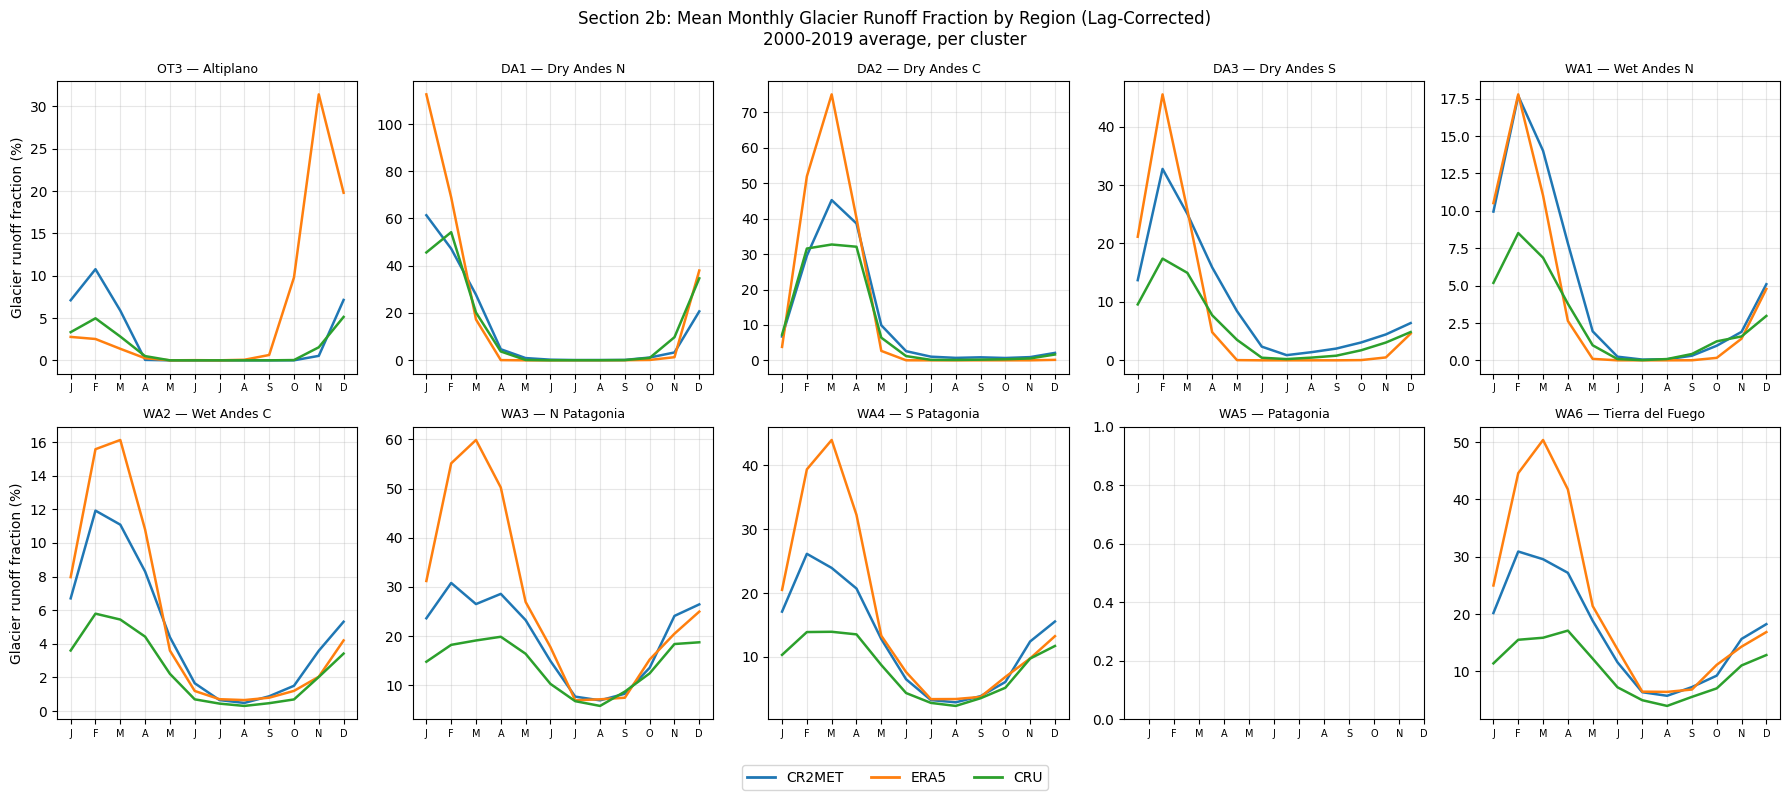

In [62]:
# Monthly seasonality by region (lag-corrected)
fig, axes = plt.subplots(2, 5, figsize=(18, 8), sharey=False)
axes_flat = axes.flatten()
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

for ax, cl in zip(axes_flat, CLUSTERS):
    gauges_in_cl = basins_in_cluster(cl)
    for ds_name in datasets:
        mon_fracs = []
        for gid in gauges_in_cl:
            m = get_lag_corrected_monthly(gid, ds_name, cl)
            if m is None:
                continue
            mf = m.groupby('month').apply(
                lambda g: g['glac_shifted'].sum() / g['q_m3_mon'].sum()
                if g['q_m3_mon'].sum() > 0 else np.nan)
            mon_fracs.append(mf)
        if mon_fracs:
            mean_mf = pd.concat(mon_fracs, axis=1).mean(axis=1)
            ax.plot(mean_mf.index, mean_mf.values*100,
                    color=DS_COLORS[ds_name], lw=1.8, label=ds_name)

    ax.set_title(f'{cl} — {REGION_LABELS[cl]}', fontsize=9)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=7)
    ax.grid(True, alpha=0.3)

axes_flat[0].set_ylabel('Glacier runoff fraction (%)')
axes_flat[5].set_ylabel('Glacier runoff fraction (%)')
handles = [plt.Line2D([0],[0], color=DS_COLORS[d], lw=2, label=d) for d in datasets]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10)
fig.suptitle('Section 2b: Mean Monthly Glacier Runoff Fraction by Region (Lag-Corrected)\n'
             '2000-2019 average, per cluster', fontsize=12)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{OUT_DIR}/section2b_monthly_seasonality_by_region.png',
            dpi=150, bbox_inches='tight')
plt.show()

WA5 has no monitored streamflow at all in the CAMELS dataset :( hence why blank

In [65]:
# Pre- vs. post-2010 comparison (calendar), annual + JFM
JFM_MONTHS = [1, 2, 3]   # captures every cluster's peak month:
                         # DA1=Jan, 7 clusters=Feb, DA2=Mar

def period_frac(gauge_id, ds_name, cluster, years, months=None):
    m = get_lag_corrected_monthly(gauge_id, ds_name, cluster)
    if m is None:
        return np.nan
    m = m[m['year'].isin(years)]
    if months is not None:
        m = m[m['month'].isin(months)]
    m = m.dropna(subset=['glac_shifted', 'q_m3_mon'])
    m = m[m['q_m3_mon'] > 0]
    if len(m) == 0:
        return np.nan
    return (m['glac_shifted'].sum() / m['q_m3_mon'].sum()) * 100

print('Section 2c: 2000-2009 vs 2010-2019, annual + JFM, lag-corrected')
print('JFM (Jan-Feb-Mar) captures every cluster\'s peak month')
print('Paired Wilcoxon signed-rank test, per cluster (CR2MET)')
print('='*95)
print(f'{"Cluster":6s} {"Scope":8s} {"n":4s} {"Base %":8s} {"Drought %":10s} '
      f'{"Δ":7s} {"p":8s} {"sig"}')
print('-'*95)

section2c_records = []
for cl in CLUSTERS:
    gauges = basins_in_cluster(cl)
    for scope, months in [('Annual', None), ('JFM', JFM_MONTHS)]:
        base_vals, dr_vals = [], []
        for gid in gauges:
            b = period_frac(gid, 'CR2MET', cl, BASELINE, months)
            d = period_frac(gid, 'CR2MET', cl, range(2010,2020), months)
            if not np.isnan(b) and not np.isnan(d):
                base_vals.append(b)
                dr_vals.append(d)
        if len(base_vals) < 3:
            continue
        try:
            stat, p = stats.wilcoxon(dr_vals, base_vals)
        except ValueError:
            p = np.nan
        section2c_records.append({
            'cluster': cl, 'scope': scope, 'n': len(base_vals),
            'base_pct': np.mean(base_vals), 'drought_pct': np.mean(dr_vals),
            'delta': np.mean(dr_vals) - np.mean(base_vals),
            'p': p, 'sig': sig_stars(p),
        })
        print(f'{cl:6s} {scope:8s} {len(base_vals):4d} '
              f'{np.mean(base_vals):8.2f} {np.mean(dr_vals):10.2f} '
              f'{np.mean(dr_vals)-np.mean(base_vals):+7.2f} '
              f'{p:8.4f} {sig_stars(p)}')

df_section2c = pd.DataFrame(section2c_records)
df_section2c.to_csv(f'{OUT_DIR}/section2c_calendar_comparison.csv', index=False)

print('\nSection 2 complete — proceed to Section 3 (Q3: relative importance)')

Section 2c: 2000-2009 vs 2010-2019, annual + JFM, lag-corrected
JFM (Jan-Feb-Mar) captures every cluster's peak month
Paired Wilcoxon signed-rank test, per cluster (CR2MET)
Cluster Scope    n    Base %   Drought %  Δ       p        sig
-----------------------------------------------------------------------------------------------
DA1    Annual     21    12.26      27.38  +15.12   0.0000 ***
DA1    JFM        21    34.26      81.05  +46.79   0.0000 ***
DA2    Annual     14     6.31      16.14   +9.83   0.0001 ***
DA2    JFM        14    14.37      36.75  +22.38   0.0001 ***
DA3    Annual     16     5.11      11.05   +5.94   0.0001 ***
DA3    JFM        16    13.34      39.10  +25.76   0.0001 ***
WA1    Annual     50     1.67       3.38   +1.71   0.0000 ***
WA1    JFM        50    10.52      16.73   +6.21   0.0000 ***
WA2    Annual     34     4.41       4.52   +0.11   0.0249 *
WA2    JFM        34     9.63       9.58   -0.05   0.6363 ns
WA3    Annual      7    20.46      20.64   +0.19   

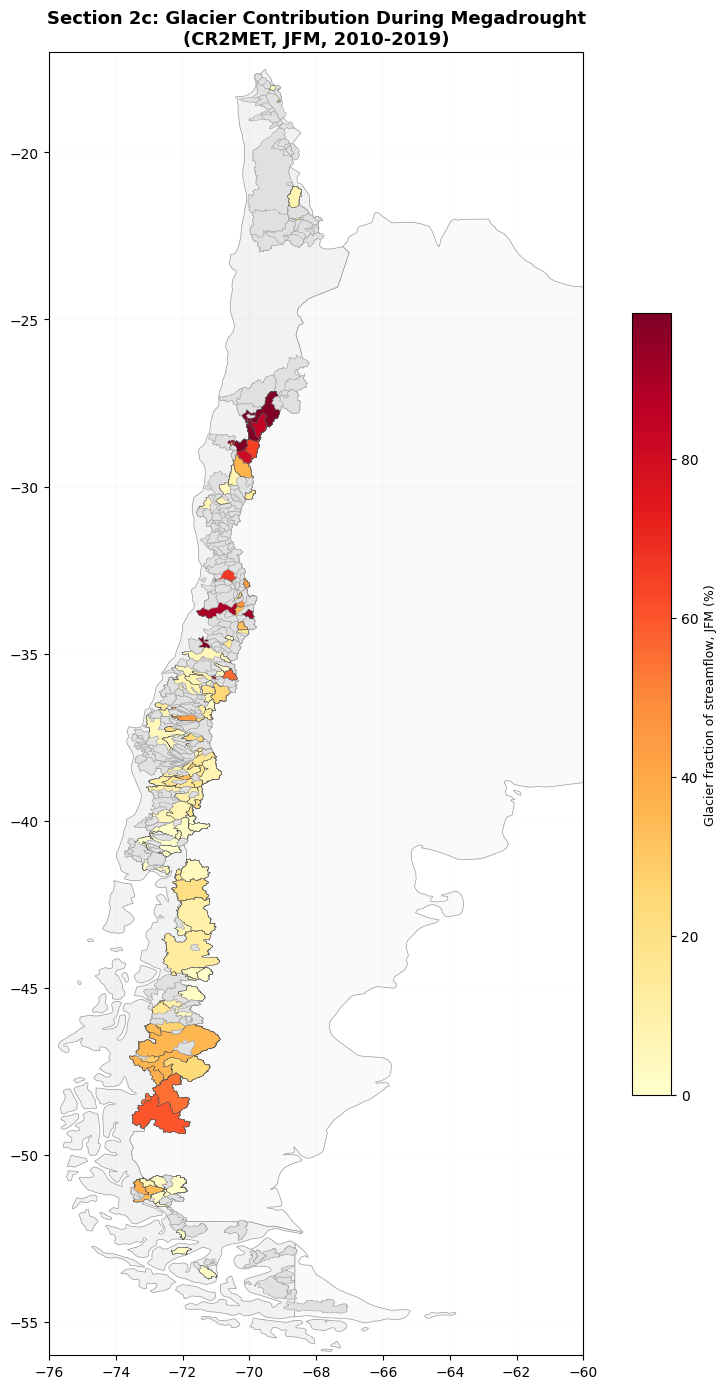

In [93]:
# Section 2c figure: standalone megadrought-period map (JFM, 2010-2019 only)
# NOTE: this cell depends on `bounds`, `has_borders`, `chile`, `arg`,
# `cmap_map`, `GREY`, `GREY_EDGE`, `BLUE_EDGE` from the Section 2a map
# cell, which must run first. Editor red-underlines here are expected
# (static linter can't see cross-cell kernel state) and not a real error
# as long as Section 2a has already been run in this session.
# FIXED: basins sorted largest-to-smallest so smaller/nested basins draw
# on top and remain visible, same fix applied to Section 2a's map.

bounds['frac_drought_JFM'] = bounds['gauge_id'].apply(
    lambda g: period_frac(g, 'CR2MET', GAUGE_INFO_FRAC[g]['clusters'][0],
                          range(2010,2020), JFM_MONTHS)
    if g in GAUGE_INFO_FRAC else np.nan)

# Re-sort by area (bounds was already sorted this way in Section 2a, but
# re-applying here makes this cell robust even if bounds got reset/reloaded
# between cells)
bounds_2c = bounds.copy()
bounds_2c['_area_deg2'] = bounds_2c.geometry.area
bounds_2c = bounds_2c.sort_values('_area_deg2', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 14))
if has_borders:
    chile.plot(ax=ax, facecolor='#f2f2f2', edgecolor='#999999', lw=0.5, zorder=0)
    arg.plot(ax=ax, facecolor='#fafafa', edgecolor='#999999', lw=0.5, zorder=0)

vals = bounds_2c['frac_drought_JFM'].values
vmax_dr = np.nanpercentile(vals, 95)
norm_dr = Normalize(vmin=0, vmax=vmax_dr)
face = [to_hex(cmap_map(norm_dr(v))) if not np.isnan(v) else GREY for v in vals]
edge = [BLUE_EDGE if not np.isnan(v) else GREY_EDGE for v in vals]
bounds_2c.plot(ax=ax, color=face, edgecolor=edge, linewidth=0.3, zorder=2)

ax.set_xlim(-76, -60); ax.set_ylim(-56, -17); ax.set_aspect('equal')
ax.grid(True, alpha=0.15, lw=0.3)
sm = ScalarMappable(cmap=cmap_map, norm=norm_dr)
cbar = fig.colorbar(sm, ax=ax, shrink=0.6)
cbar.set_label('Glacier fraction of streamflow, JFM (%)', fontsize=9)

ax.set_title('Section 2c: Glacier Contribution During Megadrought\n'
             '(CR2MET, JFM, 2010-2019)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section2c_megadrought_map.png', dpi=150, bbox_inches='tight')
plt.show()

Group 1, large and highly significant increases: DA1, DA2, DA3, WA1. Every one of these shows a statistically significant increase in glacier contribution to streamflow during the drought decade, on both annual and JFM scopes, at p<0.001 across the board. The magnitudes are large and physically meaningful, not just statistically significant. DA1 shows the most dramatic shift, JFM contribution more than doubles from 34.3% at baseline to 81.1% during drought, a 46.8 percentage point jump, the largest amplification of any cluster. DA3's JFM contribution rises from 13.3% to 39.1%, a 25.8 point increase. DA2 rises from 14.4% to 36.8%, a 22.4 point increase. WA1 shows a smaller but still highly significant rise, from 10.5% to 16.7%. This is our clearest, most robust evidence that glaciers became dramatically more important during the megadrought precisely in the clusters that also showed the strongest mass balance decline in Section 1.2, WA1 and the Central Andes, with DA1's peak-season contribution reaching a level where glacier melt was supplying the large majority of streamflow during the drought decade.

Group 2, no meaningful change: WA2, WA3, WA4, WA6. Under JFM, WA2 loses the marginal significance it showed under FMA, annual contribution moves from 4.41% to 4.52%, still a negligible 0.11 point shift, and the JFM comparison is clearly non-significant (p=0.64), confirming that WA2's earlier FMA result was a borderline artifact rather than a real seasonal signal. WA3, WA4, and WA6 show no significant change under JFM either, on annual or seasonal scope. This lines up with Section 1.2, these were the same clusters where mass balance decline was weakest or absent.

**In the clusters where glaciers are genuinely losing mass fastest, Central Andes and WA1, they are also becoming dramatically more important to streamflow during drought, most strikingly in DA1, where glacier melt's peak-season share of streamflow rose to over 80% during the megadrought.** 

In the clusters where mass balance shows little clear trend, WA2 through WA6, glacier contribution to streamflow also isn't shifting meaningfully, and the one previously borderline exception, WA2, is no longer significant once the correct peak-season window is used.

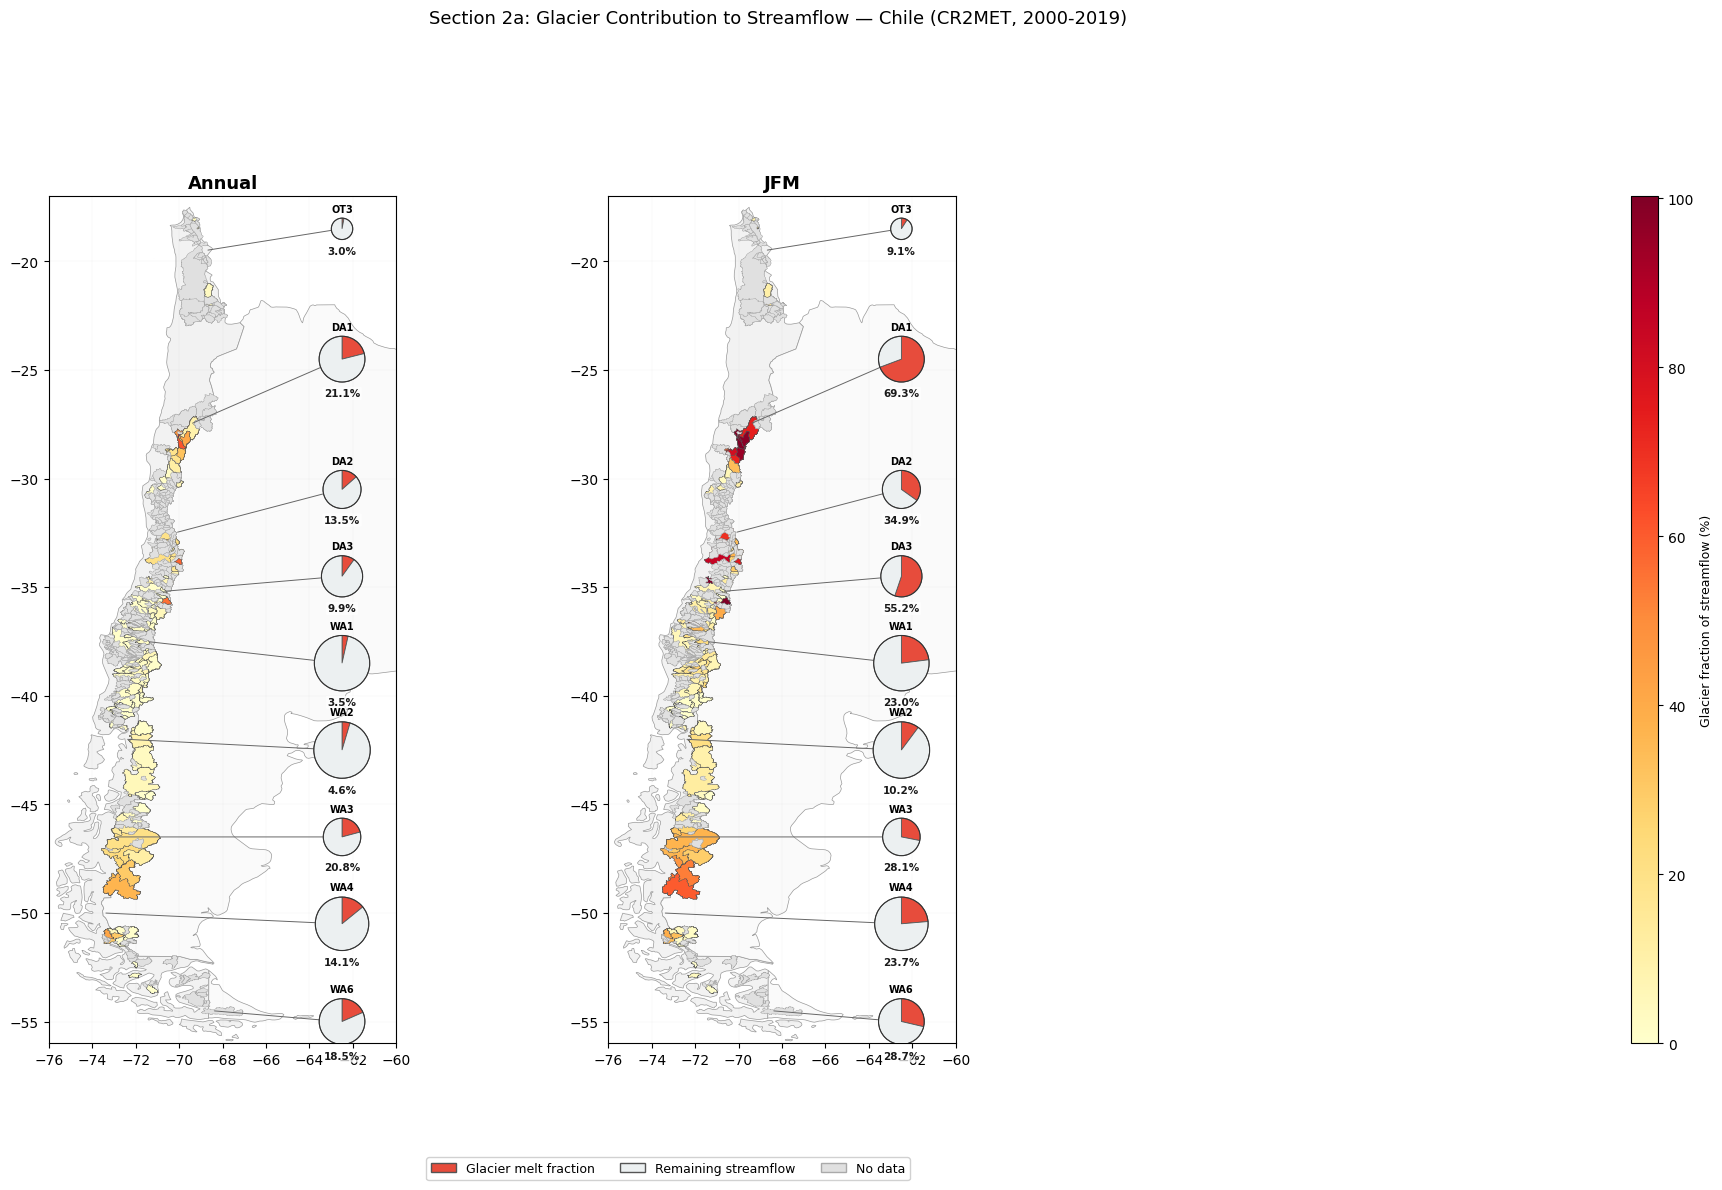

In [91]:
# Section 2a figure: Chile map, respaced pullouts to avoid label overlap
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Wedge, Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, to_hex

bounds = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)

REGION_ANCHORS = {
    'OT3': (-68.8, -19.5), 'DA1': (-69.5, -27.5),
    'DA2': (-70.2, -32.5), 'DA3': (-70.8, -35.2),
    'WA1': (-71.5, -37.5), 'WA2': (-72.5, -42.0),
    'WA3': (-73.0, -46.5), 'WA4': (-73.5, -50.0),
    'WA6': (-68.5, -54.5),
}
# FIXED: wider spacing (was every ~3.5 deg, now ~4.3 deg) to prevent
# circle/label overlap between adjacent clusters
PULLOUT_POS = {
    'OT3': (-62.5, -18.5), 'DA1': (-62.5, -24.5),
    'DA2': (-62.5, -30.5), 'DA3': (-62.5, -34.5),
    'WA1': (-62.5, -38.5), 'WA2': (-62.5, -42.5),
    'WA3': (-62.5, -46.5), 'WA4': (-62.5, -50.5),
    'WA6': (-62.5, -55.0),
}

cluster_basin_areas = {
    cl: sum(GAUGE_INFO_FRAC[g]['basin_area_km2'] for g in basins_in_cluster(cl))
    for cl in CLUSTERS if cl != 'WA5'
}
area_max = max(cluster_basin_areas.values())
CIRC_MAX, CIRC_MIN = 1.3, 0.45   # slightly reduced max so circles fit new spacing

def area_to_radius(area):
    if area <= 0:
        return CIRC_MIN
    return CIRC_MIN + (area / area_max) ** 0.5 * (CIRC_MAX - CIRC_MIN)

def regional_frac(cluster, months=None):
    fracs = []
    for gid in basins_in_cluster(cluster):
        f = basin_mean_frac(gid, 'CR2MET', cluster, months)
        if not np.isnan(f):
            fracs.append(f)
    return np.nanmean(fracs) if fracs else np.nan

for scope, months in [('Annual', None), ('JFM', JFM_MONTHS)]:
    col = f'frac_{scope}'
    bounds[col] = bounds['gauge_id'].apply(
        lambda g: basin_mean_frac(g, 'CR2MET',
                    GAUGE_INFO_FRAC[g]['clusters'][0], months)
        if g in GAUGE_INFO_FRAC else np.nan)

bounds['_area_deg2'] = bounds.geometry.area
bounds = bounds.sort_values('_area_deg2', ascending=False).reset_index(drop=True)

map_vmax = np.nanpercentile(bounds['frac_JFM'].dropna(), 95)
map_norm = Normalize(vmin=0, vmax=map_vmax)
cmap_map = plt.cm.YlOrRd
GREY, GREY_EDGE, BLUE_EDGE = '#e0e0e0', '#aaaaaa', '#555555'

try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    chile, arg = world[world['NAME']=='Chile'], world[world['NAME']=='Argentina']
    has_borders = True
except Exception:
    has_borders = False

fig = plt.figure(figsize=(22, 11))
gs = fig.add_gridspec(1, 4, width_ratios=[1,1,1,0.05], wspace=0.05)

for c_idx, (scope, months) in enumerate([('Annual', None), ('JFM', JFM_MONTHS)]):
    ax = fig.add_subplot(gs[0, c_idx])
    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2', edgecolor='#999999', lw=0.5, zorder=0)
        arg.plot(ax=ax, facecolor='#fafafa', edgecolor='#999999', lw=0.5, zorder=0)

    col = f'frac_{scope}'
    vals = bounds[col].values
    face = [to_hex(cmap_map(map_norm(v))) if not np.isnan(v) else GREY for v in vals]
    edge = [BLUE_EDGE if not np.isnan(v) else GREY_EDGE for v in vals]
    bounds.plot(ax=ax, color=face, edgecolor=edge, linewidth=0.25, zorder=2)

    for cl in CLUSTERS:
        if cl == 'WA5':
            continue
        mean_frac = regional_frac(cl, months)
        anchor, pullout = REGION_ANCHORS[cl], PULLOUT_POS[cl]
        radius = area_to_radius(cluster_basin_areas[cl])

        if np.isnan(mean_frac) or mean_frac == 0:
            ax.add_patch(plt.Circle(pullout, radius, facecolor=GREY,
                        edgecolor='#888888', lw=0.8, zorder=6))
        else:
            frac_clip = min(mean_frac/100, 1.0)
            theta1 = 90
            for size, fc in [(frac_clip, '#e74c3c'), (1-frac_clip, '#ecf0f1')]:
                theta2 = theta1 - size*360
                ax.add_patch(Wedge(pullout, radius, min(theta1,theta2), max(theta1,theta2),
                            facecolor=fc, edgecolor='#555555', lw=0.6, zorder=6))
                theta1 = theta2
            ax.add_patch(plt.Circle(pullout, radius, facecolor='none',
                        edgecolor='#333333', lw=0.8, zorder=7))
            ax.text(pullout[0], pullout[1]-radius-0.3, f'{mean_frac:.1f}%',
                   ha='center', va='top', fontsize=7.5, fontweight='bold',
                   color='#1a1a1a', zorder=8,
                   bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                            edgecolor='none', alpha=0.75))

        ax.text(pullout[0], pullout[1]+radius+0.2, cl, ha='center', va='bottom',
               fontsize=7, fontweight='bold', zorder=8)
        ax.annotate('', xy=anchor, xytext=(pullout[0]-radius*0.1, pullout[1]),
                   arrowprops=dict(arrowstyle='-', color='#666666', lw=0.7), zorder=5)

    ax.set_xlim(-76, -60); ax.set_ylim(-56, -17); ax.set_aspect('equal')
    ax.set_title(f'{scope}', fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.15, lw=0.3)

cbar_ax = fig.add_subplot(gs[0, 3])
sm = ScalarMappable(cmap=cmap_map, norm=map_norm)
fig.colorbar(sm, cax=cbar_ax).set_label('Glacier fraction of streamflow (%)', fontsize=9)

fig.legend(
    handles=[
        Patch(facecolor='#e74c3c', edgecolor='#555555', label='Glacier melt fraction'),
        Patch(facecolor='#ecf0f1', edgecolor='#555555', label='Remaining streamflow'),
        Patch(facecolor=GREY, edgecolor=GREY_EDGE, label='No data'),
    ],
    loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.45, -0.02), framealpha=0.9)

fig.suptitle('Section 2a: Glacier Contribution to Streamflow — Chile (CR2MET, 2000-2019)',
             fontsize=13, y=1.05)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section2a_map_piecharts.png', dpi=150, bbox_inches='tight')
plt.show()

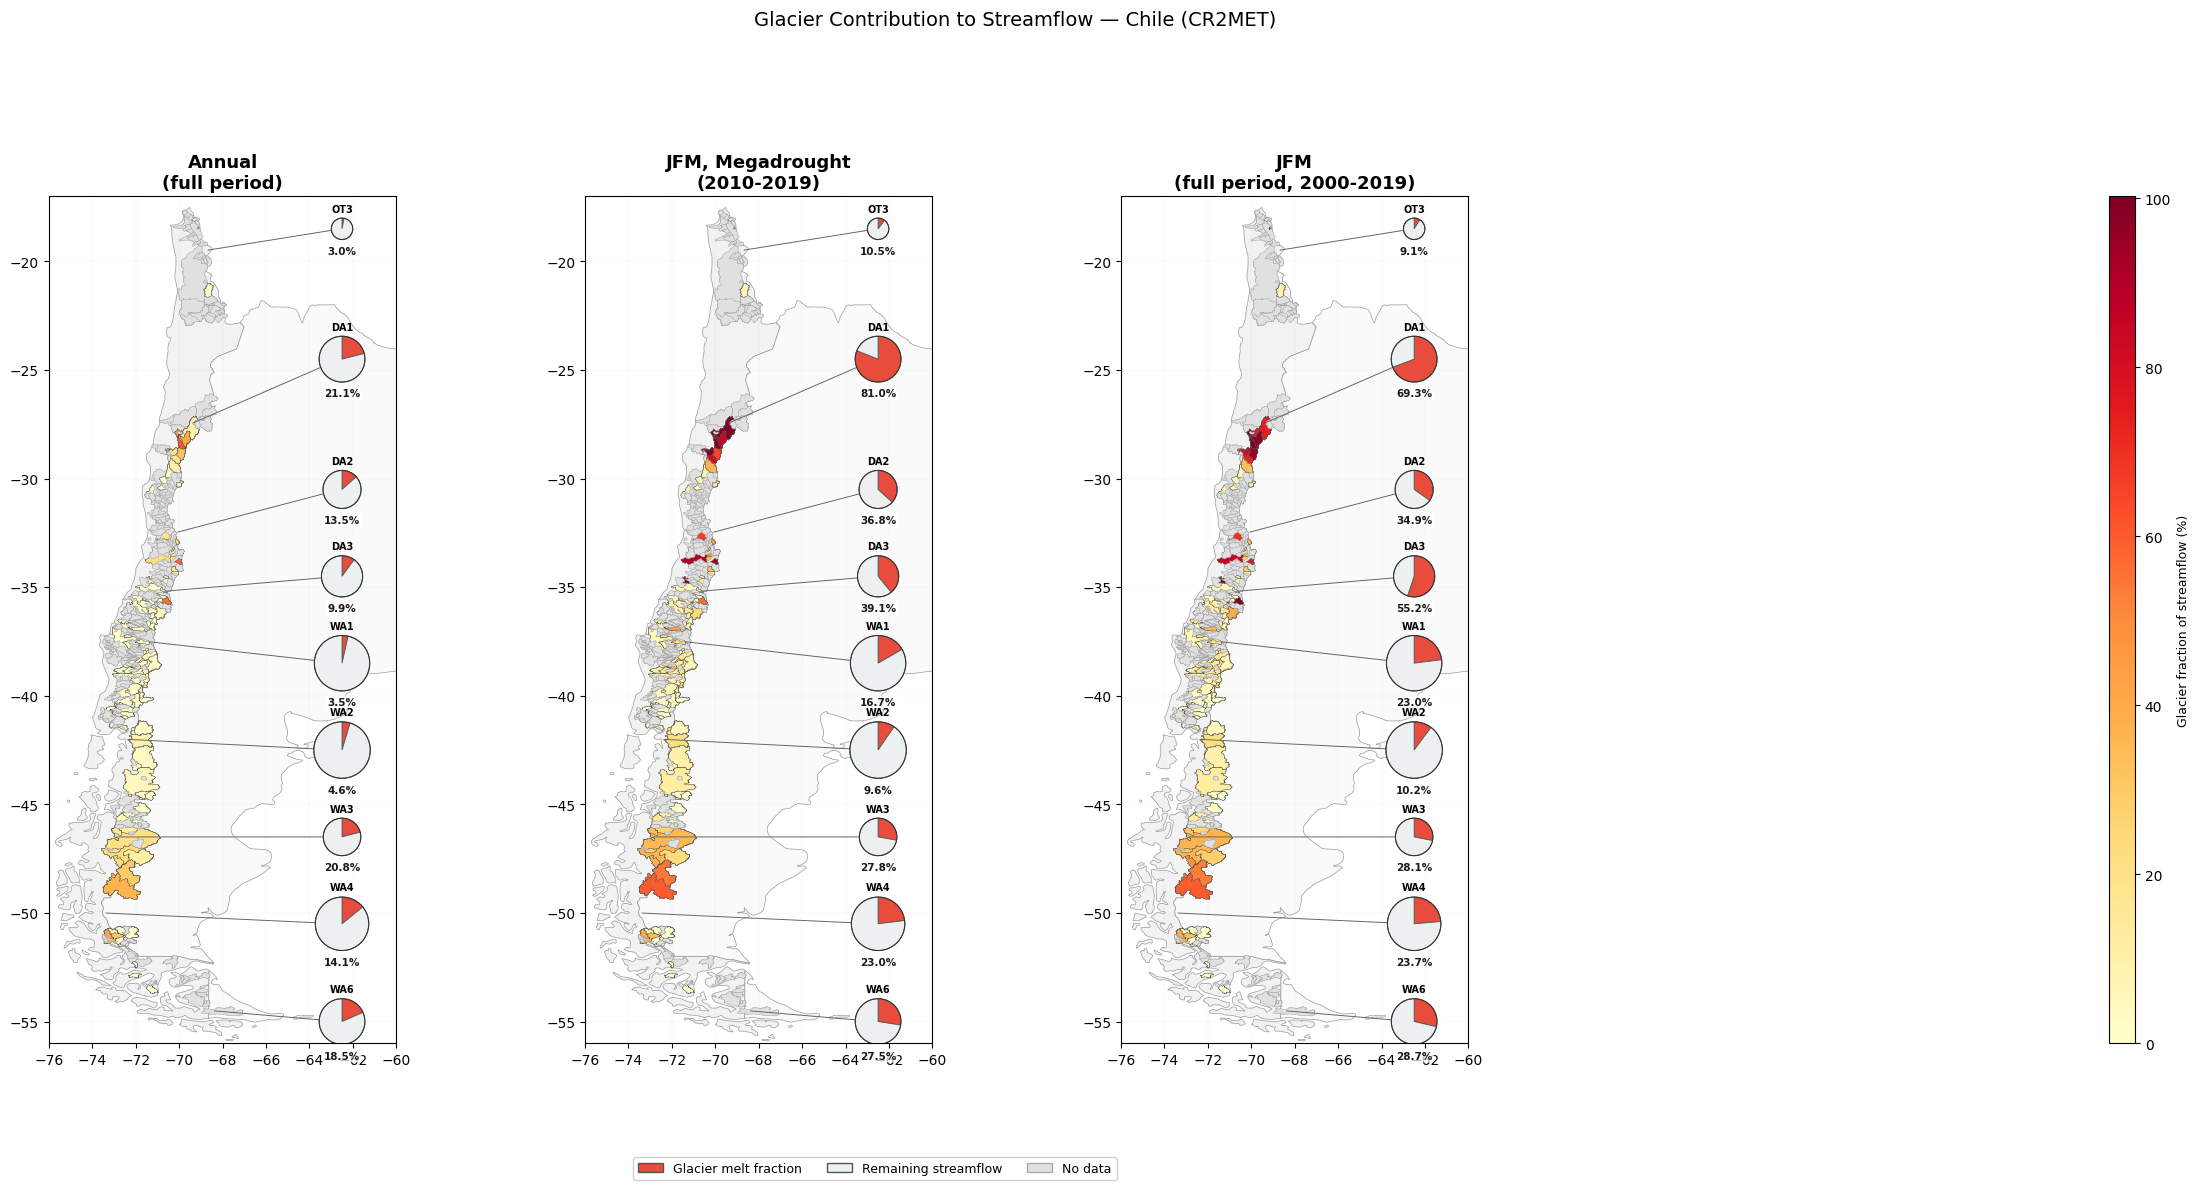

In [97]:
# Section 2a figure: Chile map, 3-panel (Annual full-period, JFM Megadrought
# 2010-2019, JFM full-period 2000-2019), respaced pullouts to avoid overlap
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.patches import Wedge, Patch
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, to_hex

bounds = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
bounds['gauge_id'] = bounds['gauge_id'].astype(str)

REGION_ANCHORS = {
    'OT3': (-68.8, -19.5), 'DA1': (-69.5, -27.5),
    'DA2': (-70.2, -32.5), 'DA3': (-70.8, -35.2),
    'WA1': (-71.5, -37.5), 'WA2': (-72.5, -42.0),
    'WA3': (-73.0, -46.5), 'WA4': (-73.5, -50.0),
    'WA6': (-68.5, -54.5),
}
PULLOUT_POS = {
    'OT3': (-62.5, -18.5), 'DA1': (-62.5, -24.5),
    'DA2': (-62.5, -30.5), 'DA3': (-62.5, -34.5),
    'WA1': (-62.5, -38.5), 'WA2': (-62.5, -42.5),
    'WA3': (-62.5, -46.5), 'WA4': (-62.5, -50.5),
    'WA6': (-62.5, -55.0),
}

cluster_basin_areas = {
    cl: sum(GAUGE_INFO_FRAC[g]['basin_area_km2'] for g in basins_in_cluster(cl))
    for cl in CLUSTERS if cl != 'WA5'
}
area_max = max(cluster_basin_areas.values())
CIRC_MAX, CIRC_MIN = 1.3, 0.45

def area_to_radius(area):
    if area <= 0:
        return CIRC_MIN
    return CIRC_MIN + (area / area_max) ** 0.5 * (CIRC_MAX - CIRC_MIN)

def regional_frac(cluster, months=None, years=None):
    fracs = []
    for gid in basins_in_cluster(cluster):
        if years is not None:
            f = period_frac(gid, 'CR2MET', cluster, years, months)
        else:
            f = basin_mean_frac(gid, 'CR2MET', cluster, months)
        if not np.isnan(f):
            fracs.append(f)
    return np.nanmean(fracs) if fracs else np.nan

# Build per-basin fraction columns: Annual (full), JFM Megadrought (2010-19),
# JFM full period (2000-19)
bounds['frac_Annual'] = bounds['gauge_id'].apply(
    lambda g: basin_mean_frac(g, 'CR2MET', GAUGE_INFO_FRAC[g]['clusters'][0], None)
    if g in GAUGE_INFO_FRAC else np.nan)
bounds['frac_JFM_drought'] = bounds['gauge_id'].apply(
    lambda g: period_frac(g, 'CR2MET', GAUGE_INFO_FRAC[g]['clusters'][0],
                          range(2010,2020), JFM_MONTHS)
    if g in GAUGE_INFO_FRAC else np.nan)
bounds['frac_JFM_full'] = bounds['gauge_id'].apply(
    lambda g: basin_mean_frac(g, 'CR2MET', GAUGE_INFO_FRAC[g]['clusters'][0], JFM_MONTHS)
    if g in GAUGE_INFO_FRAC else np.nan)

bounds['_area_deg2'] = bounds.geometry.area
bounds = bounds.sort_values('_area_deg2', ascending=False).reset_index(drop=True)

map_vmax = np.nanpercentile(bounds['frac_JFM_full'].dropna(), 95)
map_norm = Normalize(vmin=0, vmax=map_vmax)
cmap_map = plt.cm.YlOrRd
GREY, GREY_EDGE, BLUE_EDGE = '#e0e0e0', '#aaaaaa', '#555555'

try:
    world = gpd.read_file(
        'https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_countries.zip')
    chile, arg = world[world['NAME']=='Chile'], world[world['NAME']=='Argentina']
    has_borders = True
except Exception:
    has_borders = False

fig = plt.figure(figsize=(28, 11))
gs = fig.add_gridspec(1, 5, width_ratios=[1,1,1,1,0.05], wspace=0.05)

panels = [
    ('Annual\n(full period)', 'frac_Annual', None, None),
    ('JFM, Megadrought\n(2010-2019)', 'frac_JFM_drought', JFM_MONTHS, range(2010,2020)),
    ('JFM\n(full period, 2000-2019)', 'frac_JFM_full', JFM_MONTHS, None),
]

for c_idx, (title, col, months, years) in enumerate(panels):
    ax = fig.add_subplot(gs[0, c_idx])
    if has_borders:
        chile.plot(ax=ax, facecolor='#f2f2f2', edgecolor='#999999', lw=0.5, zorder=0)
        arg.plot(ax=ax, facecolor='#fafafa', edgecolor='#999999', lw=0.5, zorder=0)

    vals = bounds[col].values
    face = [to_hex(cmap_map(map_norm(v))) if not np.isnan(v) else GREY for v in vals]
    edge = [BLUE_EDGE if not np.isnan(v) else GREY_EDGE for v in vals]
    bounds.plot(ax=ax, color=face, edgecolor=edge, linewidth=0.25, zorder=2)

    for cl in CLUSTERS:
        if cl == 'WA5':
            continue
        mean_frac = regional_frac(cl, months, years)
        anchor, pullout = REGION_ANCHORS[cl], PULLOUT_POS[cl]
        radius = area_to_radius(cluster_basin_areas[cl])

        if np.isnan(mean_frac) or mean_frac == 0:
            ax.add_patch(plt.Circle(pullout, radius, facecolor=GREY,
                        edgecolor='#888888', lw=0.8, zorder=6))
        else:
            frac_clip = min(mean_frac/100, 1.0)
            theta1 = 90
            for size, fc in [(frac_clip, '#e74c3c'), (1-frac_clip, '#ecf0f1')]:
                theta2 = theta1 - size*360
                ax.add_patch(Wedge(pullout, radius, min(theta1,theta2), max(theta1,theta2),
                            facecolor=fc, edgecolor='#555555', lw=0.6, zorder=6))
                theta1 = theta2
            ax.add_patch(plt.Circle(pullout, radius, facecolor='none',
                        edgecolor='#333333', lw=0.8, zorder=7))
            ax.text(pullout[0], pullout[1]-radius-0.3, f'{mean_frac:.1f}%',
                   ha='center', va='top', fontsize=7.5, fontweight='bold',
                   color='#1a1a1a', zorder=8,
                   bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                            edgecolor='none', alpha=0.75))

        ax.text(pullout[0], pullout[1]+radius+0.2, cl, ha='center', va='bottom',
               fontsize=7, fontweight='bold', zorder=8)
        ax.annotate('', xy=anchor, xytext=(pullout[0]-radius*0.1, pullout[1]),
                   arrowprops=dict(arrowstyle='-', color='#666666', lw=0.7), zorder=5)

    ax.set_xlim(-76, -60); ax.set_ylim(-56, -17); ax.set_aspect('equal')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.15, lw=0.3)

cbar_ax = fig.add_subplot(gs[0, 4])
sm = ScalarMappable(cmap=cmap_map, norm=map_norm)
fig.colorbar(sm, cax=cbar_ax).set_label('Glacier fraction of streamflow (%)', fontsize=9)

fig.legend(
    handles=[
        Patch(facecolor='#e74c3c', edgecolor='#555555', label='Glacier melt fraction'),
        Patch(facecolor='#ecf0f1', edgecolor='#555555', label='Remaining streamflow'),
        Patch(facecolor=GREY, edgecolor=GREY_EDGE, label='No data'),
    ],
    loc='lower center', ncol=3, fontsize=9, bbox_to_anchor=(0.45, -0.02), framealpha=0.9)

fig.suptitle('Glacier Contribution to Streamflow — Chile (CR2MET)',
             fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section2a_map_piecharts_3panel.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 3 — Q3: Relative importance over time & with drought

In [66]:
# Trend significance: is glacier fraction significantly increasing? (lag-corrected)
print('Section 3a: Significant trend in glacier fraction, 2000-2019 (lag-corrected)')
print('='*80)

frac_trend_records = []
for gauge_id, info in GAUGE_INFO_FRAC.items():
    cl0 = info['clusters'][0]
    for ds_name in datasets:
        m = get_lag_corrected_monthly(gauge_id, ds_name, cl0)
        if m is None:
            continue
        ann = m.groupby('year').agg(glac=('glac_shifted','sum'),
                                    q=('q_m3_mon','sum')).reset_index()
        ann = ann[ann['q'] > 0]
        if len(ann) < 10:
            continue
        ann['frac'] = ann['glac'] / ann['q']
        slope, intercept, r, p, se = linregress(ann['year'], ann['frac'])
        frac_trend_records.append({
            'gauge_id': gauge_id, 'cluster': cl0, 'dataset': ds_name,
            'slope': slope, 'p': p,
            'sig_increase': (p < 0.05) and (slope > 0),
            'sig_decrease': (p < 0.05) and (slope < 0),
        })

df_frac_trend = pd.DataFrame(frac_trend_records)
df_frac_trend.to_csv(f'{OUT_DIR}/section3a_trend_significance.csv', index=False)

print('National % basins with significant increasing fraction:')
for ds_name in datasets:
    sub = df_frac_trend[df_frac_trend['dataset'] == ds_name]
    print(f'  {ds_name:8s} n={len(sub):3d}  '
          f'sig increase={sub["sig_increase"].mean()*100:5.1f}%  '
          f'sig decrease={sub["sig_decrease"].mean()*100:5.1f}%')

print('\n% significant increase by cluster (CR2MET):')
cr2_ft = df_frac_trend[df_frac_trend['dataset'] == 'CR2MET']
for cl in CLUSTERS:
    sub = cr2_ft[cr2_ft['cluster'] == cl]
    if len(sub) == 0:
        continue
    print(f'  {cl:6s} n={len(sub):3d}  {sub["sig_increase"].mean()*100:5.1f}% sig increase')

central_andes = cr2_ft[cr2_ft['cluster'].isin(['DA1','DA2','DA3'])]
print(f'\nCentral Andes (DA1+DA2+DA3) combined: '
      f'{central_andes["sig_increase"].mean()*100:.1f}% significant increase '
      f'(n={len(central_andes)})')

Section 3a: Significant trend in glacier fraction, 2000-2019 (lag-corrected)
National % basins with significant increasing fraction:
  CR2MET   n=135  sig increase= 55.6%  sig decrease=  0.7%
  ERA5     n=135  sig increase= 61.5%  sig decrease=  0.7%
  CRU      n=135  sig increase= 59.3%  sig decrease=  0.7%

% significant increase by cluster (CR2MET):
  OT3    n=  2    0.0% sig increase
  DA1    n= 21   57.1% sig increase
  DA2    n= 10  100.0% sig increase
  DA3    n= 14   78.6% sig increase
  WA1    n= 44   68.2% sig increase
  WA2    n= 28   35.7% sig increase
  WA3    n=  7   14.3% sig increase
  WA4    n=  7   14.3% sig increase
  WA6    n=  2    0.0% sig increase

Central Andes (DA1+DA2+DA3) combined: 73.3% significant increase (n=45)


Section 3a: **A majority of basins nationally show a statistically significant increasing trend in glacier fraction over 2000-2019 (56 to 62% depending on climate dataset), and this is heavily concentrated in the Central Andes**; DA2 hits 100% of its basins significant, DA3 79%, DA1 57%, combining to 73.3% for the Central Andes as a whole, while OT3 and WA6 show zero significant basins and WA3/WA4 are weak (14%). This matches the pattern from every other section so far, the megadrought signal is real, strong, and geographically concentrated in the same clusters every time.

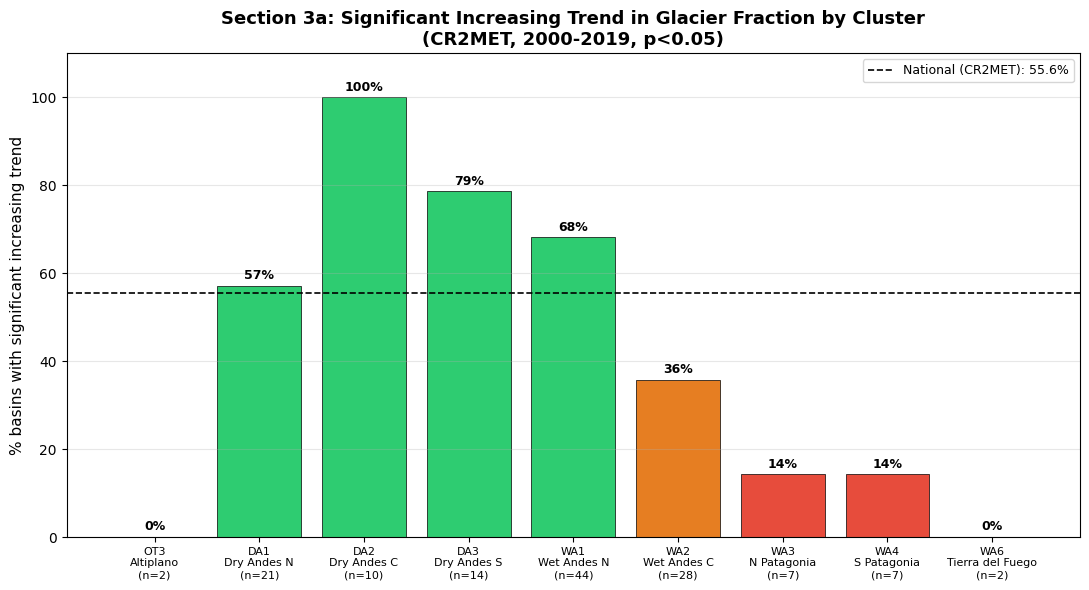

In [70]:
# Section 3a figure: % basins with significant increasing fraction, by cluster
fig, ax = plt.subplots(figsize=(11, 6))

cr2_ft = df_frac_trend[df_frac_trend['dataset'] == 'CR2MET']
cl_pcts, cl_labels, cl_n = [], [], []
for cl in CLUSTERS:
    sub = cr2_ft[cr2_ft['cluster'] == cl]
    if len(sub) == 0:
        continue
    cl_pcts.append(sub['sig_increase'].mean()*100)
    cl_labels.append(f'{cl}\n{REGION_LABELS[cl]}\n(n={len(sub)})')
    cl_n.append(len(sub))

colors_bar = ['#2ecc71' if p >= 50 else '#e67e22' if p >= 20 else '#e74c3c'
              for p in cl_pcts]
bars = ax.bar(range(len(cl_labels)), cl_pcts, color=colors_bar,
              edgecolor='k', lw=0.5)
for bar, p in zip(bars, cl_pcts):
    ax.text(bar.get_x()+bar.get_width()/2, p+1.5, f'{p:.0f}%',
            ha='center', fontsize=9, fontweight='bold')

national_pct = cr2_ft['sig_increase'].mean()*100
ax.axhline(national_pct, color='k', ls='--', lw=1.2,
           label=f'National (CR2MET): {national_pct:.1f}%')
ax.set_xticks(range(len(cl_labels)))
ax.set_xticklabels(cl_labels, fontsize=8)
ax.set_ylabel('% basins with significant increasing trend', fontsize=11)
ax.set_ylim(0, 110)
ax.set_title('Section 3a: Significant Increasing Trend in Glacier Fraction by Cluster\n'
             '(CR2MET, 2000-2019, p<0.05)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section3a_sig_increase_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [67]:
# Drought amplification: basin-relative percentile method
print(f'Section 3b: Basin-relative hydrologic drought (Q<{PCTILE_THRESHOLD}th pctile), '
      f'lag-corrected')
print('='*90)

annual_records_3b = []
for gauge_id, info in GAUGE_INFO_FRAC.items():
    cl0 = info['clusters'][0]
    for ds_name in datasets:
        m = get_lag_corrected_monthly(gauge_id, ds_name, cl0)
        if m is None:
            continue
        ann = m.groupby('year').agg(glac=('glac_shifted','sum'),
                                    q=('q_m3_mon','sum')).reset_index()
        ann = ann[ann['q'] > 0]
        if len(ann) < 8:
            continue
        ann['frac'] = ann['glac'] / ann['q']
        ann['gauge_id'], ann['dataset'], ann['cluster'] = gauge_id, ds_name, cl0
        annual_records_3b.append(ann)

df_annual_3b = pd.concat(annual_records_3b, ignore_index=True)
df_annual_3b['q_thresh'] = (df_annual_3b.groupby(['gauge_id','dataset'])['q']
                            .transform(lambda x: np.percentile(x, PCTILE_THRESHOLD)))
df_annual_3b['is_drought'] = df_annual_3b['q'] < df_annual_3b['q_thresh']

basin_amp = (df_annual_3b.groupby(['gauge_id','dataset','is_drought'])['frac']
            .mean().reset_index()
            .pivot_table(index=['gauge_id','dataset'], columns='is_drought',
                        values='frac').reset_index())
basin_amp.columns = ['gauge_id','dataset','frac_nondrought','frac_drought']
basin_amp = basin_amp.dropna(subset=['frac_drought','frac_nondrought'])
basin_amp['amp_factor'] = basin_amp['frac_drought'] / basin_amp['frac_nondrought']
basin_amp['cluster'] = basin_amp['gauge_id'].map(
    lambda g: GAUGE_INFO_FRAC[g]['clusters'][0])
basin_amp.to_csv(f'{OUT_DIR}/section3b_basin_amplification.csv', index=False)

print(f'{"Cluster":6s} {"n":4s} {"Frac non-dr":11s} {"Frac drought":12s} '
      f'{"Median amp":10s} {"p":8s} {"sig"}')
print('-'*70)
for cl in CLUSTERS:
    sub = basin_amp[(basin_amp['cluster']==cl) & (basin_amp['dataset']=='CR2MET')
                    & (basin_amp['amp_factor']<10)]
    if len(sub) < 3:
        continue
    try:
        stat, p = stats.wilcoxon(sub['frac_drought'], sub['frac_nondrought'])
    except ValueError:
        p = np.nan
    print(f'{cl:6s} {len(sub):4d} {sub["frac_nondrought"].median():11.3f} '
          f'{sub["frac_drought"].median():12.3f} {sub["amp_factor"].median():10.2f}x '
          f'{p:8.4f} {sig_stars(p)}')

Section 3b: Basin-relative hydrologic drought (Q<20th pctile), lag-corrected
Cluster n    Frac non-dr Frac drought Median amp p        sig
----------------------------------------------------------------------
DA1      21       0.112        0.270       2.41x   0.0000 ***
DA2      10       0.110        0.313       2.94x   0.0020 **
DA3      14       0.018        0.078       2.24x   0.0002 ***
WA1      43       0.016        0.032       1.82x   0.0000 ***
WA2      30       0.015        0.022       1.50x   0.0000 ***
WA3       7       0.290        0.408       1.41x   0.0156 *
WA4       7       0.045        0.056       1.62x   0.0156 *


This cell defines each basin's own drought years as the years falling below the 20th percentile of that basin's own annual streamflow, then compares glacier fraction during those drought years versus all other years. It found that **glacier contribution to streamflow is significantly higher during drought years in every cluster reported**, ranging from 1.4 to 2.9 times higher, strongest in the Central Andes (DA1 2.41x, DA2 2.94x, DA3 2.24x) and weaker but still significant in the wetter clusters (WA1 1.82x, WA2 1.50x, WA3 1.41x, WA4 1.62x).

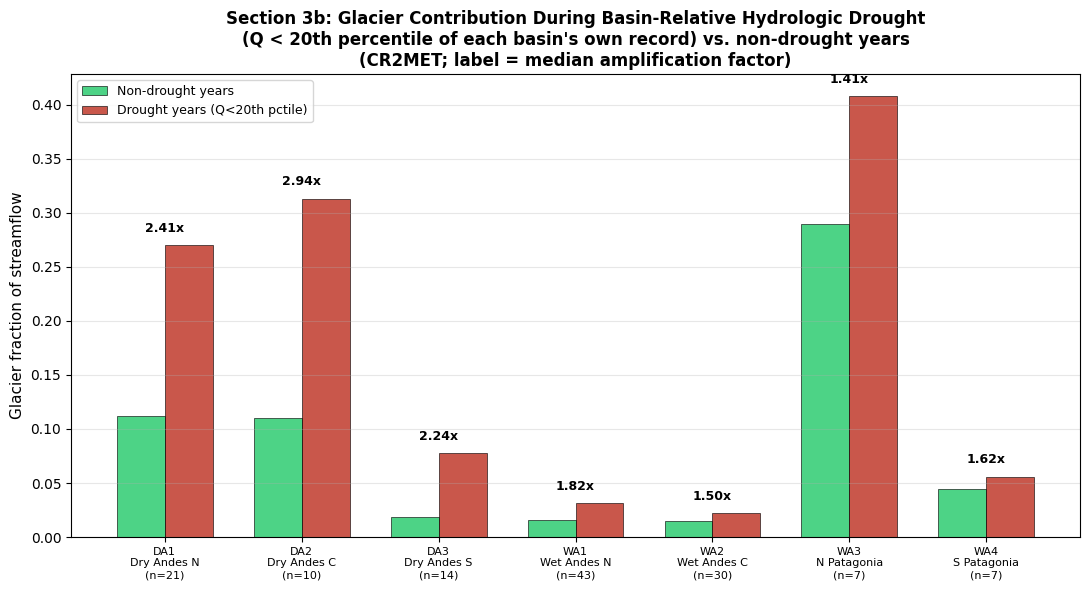

In [73]:
# Section 3b figure (fixed): non-drought vs drought fraction, by cluster
fig, ax = plt.subplots(figsize=(11, 6))

cl_nondr, cl_dr, cl_amp, cl_labels = [], [], [], []
for cl in CLUSTERS:
    sub = basin_amp[(basin_amp['cluster']==cl) & (basin_amp['dataset']=='CR2MET')
                    & (basin_amp['amp_factor']<10)]
    if len(sub) < 3:
        continue
    cl_nondr.append(sub['frac_nondrought'].median())
    cl_dr.append(sub['frac_drought'].median())
    cl_amp.append(sub['amp_factor'].median())
    cl_labels.append(f'{cl}\n{REGION_LABELS[cl]}\n(n={len(sub)})')

x = np.arange(len(cl_labels))
width = 0.35
ax.bar(x - width/2, cl_nondr, width, label='Non-drought years',
       color='#2ecc71', alpha=0.85, edgecolor='k', lw=0.5)
ax.bar(x + width/2, cl_dr, width, label=f'Drought years (Q<{PCTILE_THRESHOLD}th pctile)',
       color='#c0392b', alpha=0.85, edgecolor='k', lw=0.5)

for i, (nd, dr, amp) in enumerate(zip(cl_nondr, cl_dr, cl_amp)):
    ax.text(i, max(nd, dr) + max(cl_dr)*0.03, f'{amp:.2f}x',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cl_labels, fontsize=8)
ax.set_ylabel('Glacier fraction of streamflow', fontsize=11)
ax.set_title('Section 3b: Glacier Contribution During Basin-Relative Hydrologic Drought\n'
             f'(Q < {PCTILE_THRESHOLD}th percentile of each basin\'s own record) vs. non-drought years\n'
             '(CR2MET; label = median amplification factor)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section3b_drought_vs_nondrought_by_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()

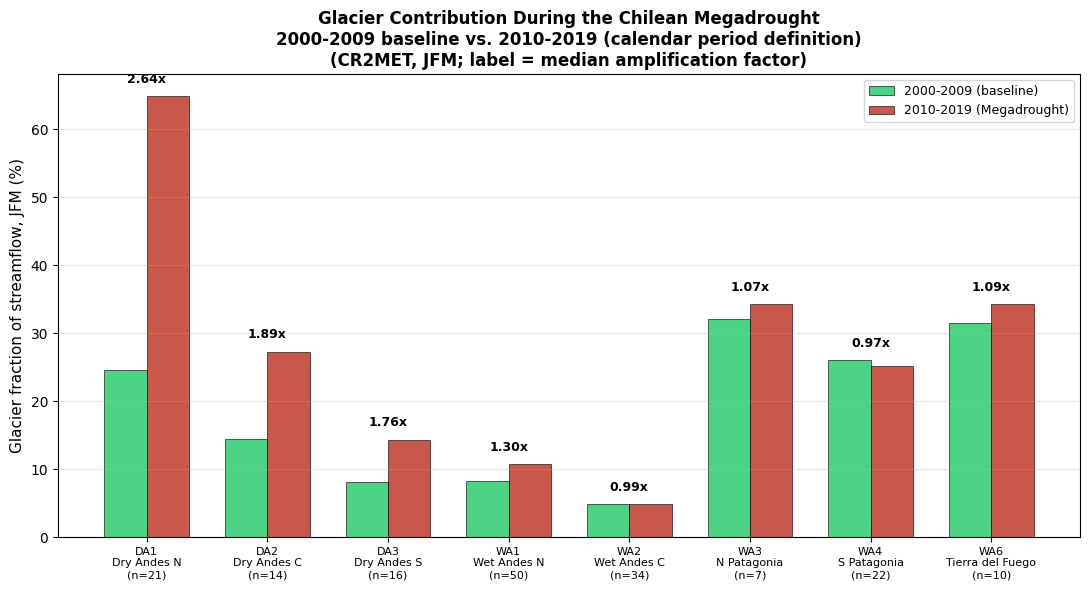

In [96]:
# Megadrought calendar comparison figure (2010-2019 vs 2000-2009 baseline)
# Same style as Section 3b, but using the calendar period definition
# (fixed 2010-2019 drought window) instead of basin-relative percentile
# drought years. JFM scope used since it captures every cluster's peak
# ablation month.

fig, ax = plt.subplots(figsize=(11, 6))

cl_base, cl_dr, cl_amp, cl_labels = [], [], [], []
for cl in CLUSTERS:
    gauges = basins_in_cluster(cl)
    base_vals, dr_vals = [], []
    for gid in gauges:
        b = period_frac(gid, 'CR2MET', cl, BASELINE, JFM_MONTHS)
        d = period_frac(gid, 'CR2MET', cl, range(2010,2020), JFM_MONTHS)
        if not np.isnan(b) and not np.isnan(d) and b > 0:
            base_vals.append(b)
            dr_vals.append(d)
    if len(base_vals) < 3:
        continue

    med_base = np.median(base_vals)
    med_dr = np.median(dr_vals)
    amp = med_dr / med_base if med_base > 0 else np.nan

    cl_base.append(med_base)
    cl_dr.append(med_dr)
    cl_amp.append(amp)
    cl_labels.append(f'{cl}\n{REGION_LABELS[cl]}\n(n={len(base_vals)})')

x = np.arange(len(cl_labels))
width = 0.35
ax.bar(x - width/2, cl_base, width, label='2000-2009 (baseline)',
       color='#2ecc71', alpha=0.85, edgecolor='k', lw=0.5)
ax.bar(x + width/2, cl_dr, width, label='2010-2019 (Megadrought)',
       color='#c0392b', alpha=0.85, edgecolor='k', lw=0.5)

for i, (base, dr, amp) in enumerate(zip(cl_base, cl_dr, cl_amp)):
    ax.text(i, max(base, dr) + max(cl_dr)*0.03, f'{amp:.2f}x',
            ha='center', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(cl_labels, fontsize=8)
ax.set_ylabel('Glacier fraction of streamflow, JFM (%)', fontsize=11)
ax.set_title('Glacier Contribution During the Chilean Megadrought\n'
             '2000-2009 baseline vs. 2010-2019 (calendar period definition)\n'
             '(CR2MET, JFM; label = median amplification factor)',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/megadrought_calendar_baseline_vs_drought_by_cluster.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [68]:
# Q-decline vs. melt-change decomposition (calendar period)
decomp_records_3c = []
for gauge_id, info in GAUGE_INFO_FRAC.items():
    cl0 = info['clusters'][0]
    for ds_name in datasets:
        m = get_lag_corrected_monthly(gauge_id, ds_name, cl0)
        if m is None:
            continue
        base = m[m['year'].isin(BASELINE)]
        drgt = m[m['year'].isin(range(2010,2020))]
        if len(base) == 0 or len(drgt) == 0:
            continue
        glac_base = base['glac_shifted'].sum() / base['year'].nunique()
        q_base    = base['q_m3_mon'].sum() / base['year'].nunique()
        glac_dr   = drgt['glac_shifted'].sum() / drgt['year'].nunique()
        q_dr      = drgt['q_m3_mon'].sum() / drgt['year'].nunique()
        if q_base == 0 or q_dr == 0:
            continue
        frac_base, frac_dr = glac_base/q_base, glac_dr/q_dr
        delta = frac_dr - frac_base
        if abs(delta) < 1e-10:
            continue
        frac_cf_q    = glac_dr   / q_base
        frac_cf_glac = glac_base / q_dr
        pct_q = (frac_cf_glac - frac_base) / delta * 100
        pct_m = (frac_cf_q    - frac_base) / delta * 100
        decomp_records_3c.append({
            'gauge_id': gauge_id, 'cluster': cl0, 'dataset': ds_name,
            'delta_frac': delta,
            'pct_q_decline': np.clip(pct_q, -200, 200),
            'pct_melt_chg':  np.clip(pct_m, -200, 200),
        })

df_decomp_3c = pd.DataFrame(decomp_records_3c)
amplifying_3c = df_decomp_3c[df_decomp_3c['delta_frac'] > 0]
amplifying_3c.to_csv(f'{OUT_DIR}/section3c_decomposition.csv', index=False)

print('Section 3c: Q-decline vs melt-change (amplifying basins only, pooled datasets)')
print(f'n={len(amplifying_3c)}  '
      f'Q-decline median={amplifying_3c["pct_q_decline"].median():+.1f}%  '
      f'melt-change median={amplifying_3c["pct_melt_chg"].median():+.1f}%')
print(f'{len(amplifying_3c)}/{len(df_decomp_3c)} basin-datasets show amplifying '
      f'fraction ({len(amplifying_3c)/len(df_decomp_3c)*100:.1f}%)')

Section 3c: Q-decline vs melt-change (amplifying basins only, pooled datasets)
n=375  Q-decline median=+94.9%  melt-change median=+2.8%
375/411 basin-datasets show amplifying fraction (91.2%)


Section 3c: This cell decomposes the change in glacier fraction between the two calendar periods into how much is explained by streamflow declining versus glacier melt increasing, using a counterfactual approach, and restricts to basins where the fraction actually increased, pooled across all three datasets. The result confirms what we already suspected, **streamflow decline explains the overwhelming majority of the amplification (median 95%), while melt change contributes almost nothing (median 3%), meaning glacier buffering during drought is driven almost entirely by the denominator shrinking, not by glaciers producing more water.**

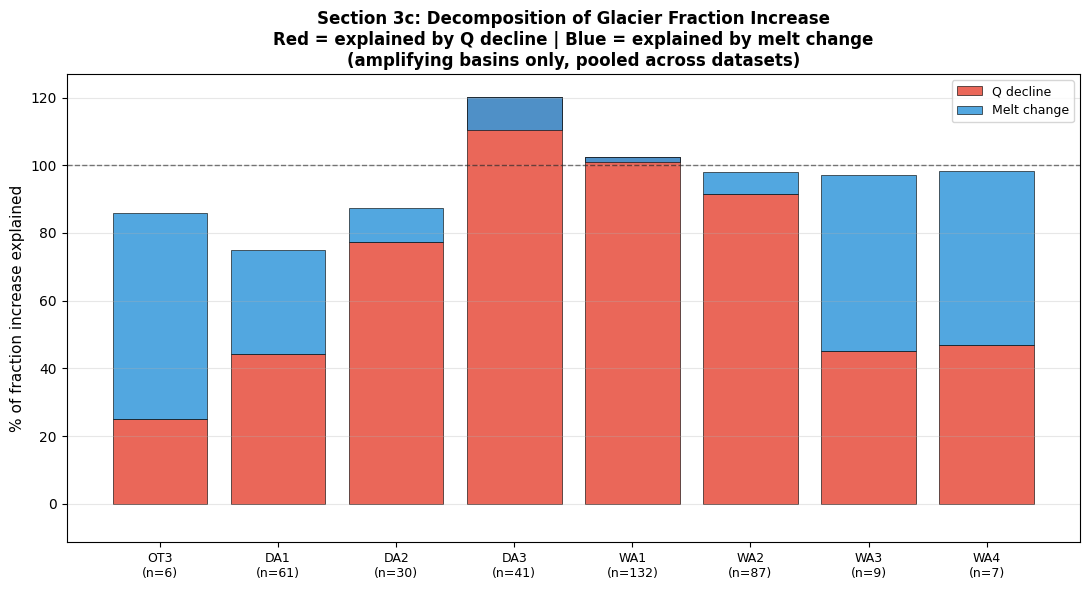

In [74]:
# Section 3c figure (fixed): explicit ylim to prevent clipping
fig, ax = plt.subplots(figsize=(11, 6))

cl_q, cl_melt, cl_labels = [], [], []
for cl in CLUSTERS:
    sub = amplifying_3c[amplifying_3c['cluster'] == cl]
    if len(sub) < 3:
        continue
    cl_q.append(sub['pct_q_decline'].median())
    cl_melt.append(sub['pct_melt_chg'].median())
    cl_labels.append(f'{cl}\n(n={len(sub)})')

x = np.arange(len(cl_labels))
stack_totals = [q + m for q, m in zip(cl_q, cl_melt)]
ymax = max(stack_totals + [100]) * 1.15   # headroom above tallest stack

ax.bar(x, cl_q, label='Q decline', color='#e74c3c', alpha=0.85, edgecolor='k', lw=0.5)
ax.bar(x, cl_melt, bottom=cl_q, label='Melt change', color='#3498db',
       alpha=0.85, edgecolor='k', lw=0.5)
ax.axhline(100, color='k', lw=1, ls='--', alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(cl_labels, fontsize=9)
ax.set_ylabel('% of fraction increase explained', fontsize=11)
ax.set_ylim(min(0, min(cl_melt)*1.15) if min(cl_melt) < 0 else 0, ymax)
ax.set_title('Section 3c: Decomposition of Glacier Fraction Increase\n'
             'Red = explained by Q decline | Blue = explained by melt change\n'
             '(amplifying basins only, pooled across datasets)',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(f'{OUT_DIR}/section3c_decomposition_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

In [95]:
# Section 3d — MLR explanatory power (monthly dummies, national panel)
# FIXED: LMG computation now uses QR decomposition for sequential R²
# contributions instead of refitting 15 separate LinearRegression models
# per permutation (roughly 10-15x faster, same underlying statistic).

def load_camels_mon(fname):
    df = pd.read_csv(f'{CAMELS_FULL}/{fname}')
    df = df[(df['year']>=2000)&(df['year']<=2019)].copy()
    gauge_cols = [c for c in df.columns if c not in ['date','year','month','day']]
    return df[['year','month']+gauge_cols]

precip_df = load_camels_mon('precip_cr2met_mm_mon.csv')
tmean_df  = load_camels_mon('tmean_cr2met_C_mon.csv')
pet_df    = load_camels_mon('pet_hargreaves_mm_mon.csv')

MONTH_DUMMY_COLS = [f'month_{mo}' for mo in range(2, 13)]  # month 1 = reference
PREDICTORS = ['glacier_runoff_m3','precip_mm','tmean_C','pet_mm'] + MONTH_DUMMY_COLS
PRED_LABELS = {'glacier_runoff_m3':'Glacier runoff','precip_mm':'Precipitation',
              'tmean_C':'Temperature','pet_mm':'PET'}

REG_DATA = {}
for ds_name in datasets:
    rows = []
    for gauge_id, info in GAUGE_INFO_FRAC.items():
        cl0 = info['clusters'][0]
        m = get_lag_corrected_monthly(gauge_id, ds_name, cl0)
        if m is None or len(m) == 0:
            continue
        gid = str(gauge_id)
        mc = m.rename(columns={'glac_shifted':'glacier_runoff_m3'}).copy()
        for df_src, col in [(precip_df,'precip_mm'),(tmean_df,'tmean_C'),(pet_df,'pet_mm')]:
            if gid in df_src.columns:
                clim = df_src[['year','month',gid]].rename(columns={gid:col})
                mc = mc.merge(clim, on=['year','month'], how='left')
            else:
                mc[col] = np.nan
        for mo in range(2,13):
            mc[f'month_{mo}'] = (mc['month']==mo).astype(int)
        mc['gauge_id'], mc['cluster'] = gauge_id, cl0
        rows.append(mc)
    if rows:
        REG_DATA[ds_name] = pd.concat(rows, ignore_index=True)
        print(f'{ds_name}: {len(REG_DATA[ds_name]):,} obs')

def lmg_approx_fast(df, predictors, target='q_m3_mon', n_samples=1000, seed=42):
    """Fast Monte Carlo LMG via QR decomposition. For a given permutation
    order, projecting the centered target onto the orthonormal basis Q
    (from QR of the ordered, centered design matrix) gives each
    predictor's sequential contribution to R² in ONE linear algebra
    operation, instead of refitting the model at each of the 15 steps.
    Mathematically equivalent to the slower refit-based version."""
    rng = np.random.RandomState(seed)
    sub = df.dropna(subset=predictors+[target]).copy()
    sub = sub[sub[target] > 0]
    X_full = sub[predictors].values.astype(float)
    y = sub[target].values.astype(float)

    X_c = X_full - X_full.mean(axis=0)
    y_c = y - y.mean()
    TSS = np.sum(y_c**2)

    n_pred = len(predictors)
    lmg = {p: 0.0 for p in predictors}

    for _ in range(n_samples):
        order = rng.permutation(n_pred)
        Xo = X_c[:, order]
        Q, R = np.linalg.qr(Xo)
        proj = Q.T @ y_c
        seq_r2_contrib = (proj**2) / TSS

        for idx, p_idx in enumerate(order):
            lmg[predictors[p_idx]] += seq_r2_contrib[idx]

    return {p: v/n_samples for p, v in lmg.items()}

print('\nSection 3d: National panel regression (monthly dummies), all datasets')
print('='*70)
PANEL_RESULTS = {}
for ds_name in datasets:
    sub = REG_DATA[ds_name].dropna(subset=PREDICTORS+['q_m3_mon'])
    sub = sub[sub['q_m3_mon'] > 0]
    X, y = sub[PREDICTORS].values, sub['q_m3_mon'].values
    mod = LinearRegression().fit(X, y)
    pred = mod.predict(X)
    ss_res = np.sum((y-pred)**2)
    r2 = 1 - ss_res/np.sum((y-y.mean())**2)
    n, k = len(y), X.shape[1]
    mse = ss_res/(n-k-1)
    se_glac = np.sqrt(mse * np.linalg.inv(X.T@X).diagonal()[0])
    t_glac = mod.coef_[0]/se_glac
    p_glac = 2*stats.t.sf(abs(t_glac), df=n-k-1)
    PANEL_RESULTS[ds_name] = {'r2':r2,'n':n,'p_glacier':p_glac}
    print(f'{ds_name:8s} n={n:,}  R²={r2:.3f}  glacier p={p_glac:.4g} {sig_stars(p_glac)}')

print('\nComputing LMG relative importance (glacier runoff), fast QR method, n=1000...')
for ds_name in datasets:
    sub = REG_DATA[ds_name].dropna(subset=PREDICTORS+['q_m3_mon'])
    sub = sub[sub['q_m3_mon'] > 0]
    lmg = lmg_approx_fast(sub, PREDICTORS, n_samples=1000)
    r2 = PANEL_RESULTS[ds_name]['r2']
    lmg_glac = lmg['glacier_runoff_m3']
    print(f'  {ds_name}: LMG(glacier)={lmg_glac:.4f}  '
          f'({lmg_glac/r2*100:.1f}% of R²={r2:.3f})')
    PANEL_RESULTS[ds_name]['lmg_glacier'] = lmg_glac
    PANEL_RESULTS[ds_name]['lmg_glacier_pct'] = lmg_glac/r2*100

print('\nSection 3d complete')

CR2MET: 24,432 obs
ERA5: 24,432 obs
CRU: 24,432 obs

Section 3d: National panel regression (monthly dummies), all datasets
CR2MET   n=23,275  R²=0.360  glacier p=1.273e-29 ***
ERA5     n=23,275  R²=0.297  glacier p=2.658e-90 ***
CRU      n=23,275  R²=0.345  glacier p=1.245e-19 ***

Computing LMG relative importance (glacier runoff), fast QR method, n=1000...
  CR2MET: LMG(glacier)=0.1188  (33.0% of R²=0.360)
  ERA5: LMG(glacier)=0.0936  (31.5% of R²=0.297)
  CRU: LMG(glacier)=0.1112  (32.2% of R²=0.345)

Section 3d complete


In this national panel regression controlling for precipitation, temperature, PET, and seasonality, glacier runoff is a highly significant predictor of monthly streamflow and uniquely explains roughly 31 to 33% of the variance the model captures, confirming that glaciers are not just occasionally important during drought, but a consistently meaningful driver of streamflow variability nationally.

## SUMMARY 

**Q1: How are glaciers evolving 2000-2019?** Mass balance declined significantly over the full record in 7 of 9 clusters (weakest/absent in OT3 and WA5), most robustly in WA1 and the Central Andes, defined here as DA1, DA2, and DA3 (Dry Andes North, Central, and South, roughly 27-36°S), and glacier volume declined significantly everywhere (1.4% to 23% loss depending on cluster). The decline is mostly driven by falling snowfall (accumulation) rather than rising melt (ablation), except in DA1, where rising melt is the dominant driver.

**Q2: How much do glaciers contribute to streamflow?** Nationally, glacier melt supplies roughly 7 to 12% of annual streamflow (varies by climate dataset), rising to 26 to 50%+ in each region's actual peak month (January for DA1, March for DA2, February elsewhere), with DA1 and DA2 by far the most glacier-dependent basins in the country. For WA1 specifically: annual contribution is small (2 to 4%), rising to 9 to 20% in February (its peak month), and 14 to 41% in JFM specifically during the drought decade, up from 11% JFM at baseline, a statistically significant increase. This used lag-corrected monthly data throughout, since DA2, WA2, WA3, WA4, and WA6 showed genuine one-month routing delays between melt and streamflow, though WA1 itself showed no genuine lag once seasonal aliasing was removed.

**Q3: How is glacier importance changing over time and with drought?** Glacier fraction, defined as the percentage of monthly or annual streamflow attributable to glacier melt, shows a significant increasing trend in a majority of basins nationally (56 to 62%), concentrated almost entirely in the Central Andes and WA1, and is 1.4 to 2.9 times higher during each basin's own drought years than non-drought years. This buffering is driven overwhelmingly by declining streamflow, not increased melt, roughly 95% of the amplification is explained by Q decline versus about 3% by melt change, meaning glacier buffering during drought is largely a passive consequence of everything else drying up, not glaciers actively producing more water.

**Climate dataset choice:** ERA5 estimates the highest glacier melt volumes and the highest glacier contribution to streamflow of the three datasets, CRU the lowest. This spread is explained by precipitation, not temperature, the three datasets disagree about how much snow falls on glaciers by nearly the same margin that they disagree about total melt (67.6 vs. 66.9 km³/yr nationally), so a dataset simulating more snowfall produces correspondingly more melt to still hit the same calibrated mass balance target, rather than the datasets independently disagreeing about melt efficiency or temperature. Despite this, all three datasets agree closely on relative glacier volume loss and largely agree on which clusters show significant drought-related change, so dataset choice affects absolute magnitudes more than it affects the overall spatial and temporal pattern. In a national panel regression controlling for precipitation, temperature, PET, and seasonality, glacier runoff is a highly significant predictor of monthly streamflow and uniquely explains roughly 31 to 33% of the variance the model captures, confirming that glaciers are not just occasionally important during drought, but a consistently meaningful driver of streamflow variability nationally.